# Лабораторная работа 1. Введение в Big Data

*Аношин Антон, магистратура 02.04.03.*

В качестве датасета решил взять не вариант из таблицы, а свои данные - карточки ДТП с stat.gibdd.ru по всем регионам
России с 2015 года по август 2026-го. Собирал их для магистерской диссертации по прогнозу очагов аварийности: есть время, координаты и внешние факторы вроде погоды и освещения.

Так как не один из сценариев не подходит под мой датасет, я выбрал свой: Прогнозирование ДТП.

Данные у меня лежат слоями: ответы от API, журнал загрузчика,
справочники, разобранные таблицы ДТП, участников и машин, а также признаки и прогнозы модели.

## Подготовка

In [80]:
import os, io, gc, json, glob, time, random, math, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

import zstandard as zstd
import fastavro

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_DIR = Path(os.environ.get("DTP_DATA_DIR", "/home/restup/Projects/DTP/hotspot-ai/experiment/data"))

WORK_DIR = Path(os.environ.get("LAB1_WORK_DIR", "./_work"))
WORK_DIR.mkdir(exist_ok=True, parents=True)

def human(n_bytes: float) -> str:
    for unit in ["Б", "КБ", "МБ", "ГБ", "ТБ", "ПБ"]:
        if abs(n_bytes) < 1024:
            return f"{n_bytes:,.1f} {unit}".replace(",", " ")
        n_bytes /= 1024
    return f"{n_bytes:.1f} ЭБ"

GB = 1024**3
TB = 1024**4
print("DATA_DIR =", DATA_DIR)

DATA_DIR = /home/restup/Projects/DTP/hotspot-ai/experiment/data


Таблицу ДТП читаем по годам и склеиваем. Если читать папку целиком, pandas спотыкается о колонку year:

In [ ]:
# загрузка accidents по годам
ACC_FILES = sorted(glob.glob(str(DATA_DIR / "clean/accidents/year=*/part.parquet")))
print(f"Файлов accidents: {len(ACC_FILES)}")

BASE_COLS = ["accident_id", "reg_code", "reg_name", "empt_number", "dt", "year", "month", "hour", "weekday",
             "lat", "lon", "accident_kind", "vehicles_n", "participants_n", "dead_n", "injured_n",
             "district", "settlement", "street", "road", "road_significance", "road_category",
             "street_category", "km", "m", "road_surface", "lighting"]

def load_accidents(columns=None) -> pd.DataFrame:
    parts = [pd.read_parquet(f, columns=columns) for f in ACC_FILES]
    return pd.concat(parts, ignore_index=True)

t0 = time.perf_counter()
acc = load_accidents(BASE_COLS)
for c in ["reg_name", "accident_kind", "road_significance", "road_category", "street_category",
          "road_surface", "lighting"]:
    acc[c] = acc[c].astype("category")
print(f"Загружено {len(acc):,} ДТП × {acc.shape[1]} колонок за {time.perf_counter()-t0:.1f} с; "
      f"память pandas: {human(acc.memory_usage(deep=True).sum())}")
print("Период:", acc["dt"].min(), "-", acc["dt"].max())
acc.head(3).T

Файлов accidents: 12
Загружено 1,730,272 ДТП × 27 колонок за 1.4 с; память pandas: 474.4 МБ
Период: 2015-01-01 00:01:00 — 2026-08-31 23:58:00


,0,1,2
accident_id,1101-20150131-hf55effab88cd,1101-20150131-h9ecaf9aee183,1101-20150131-h7bf3df82707b
reg_code,1101,1101,1101
reg_name,Алтайский край,Алтайский край,Алтайский край
empt_number,NaN,NaN,NaN
dt,2015-01-31 05:00:00,2015-01-31 07:30:00,2015-01-31 14:15:00
year,2015,2015,2015
month,1,1,1
hour,5,7,14
weekday,5,5,5
lat,53.333056,52.245833,53.274167


In [82]:
# чтение папки целиком падает на типе year
try:
    pd.read_parquet(DATA_DIR / "clean/accidents")
except Exception as e:
    print(type(e).__name__, "→", str(e)[:200])

ArrowTypeError → Unable to merge: Field year has incompatible types: int64 vs dictionary<values=int32, indices=int32, ordered=0>


## Часть 1. Volume

### 1.1. Текущий объём

Посмотрим, сколько всё занимает на диске.

In [83]:
def dir_size(path: Path) -> tuple[int, int]:
    total, n = 0, 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f)); n += 1
    return total, n

manifest_all = pd.read_json(DATA_DIR / "manifest.jsonl", lines=True)
manifest = (manifest_all.sort_values("fetched_at")
            .drop_duplicates(["reg_code", "year", "month"], keep="last")
            .reset_index(drop=True))
print(f"Записей: {len(manifest_all):,}, уникальных (регион, месяц): {len(manifest):,}")

inventory = []
inventory.append(("raw (json.zst)", manifest["bytes"].sum(), len(manifest)))
for layer in ["clean/accidents", "clean/participants", "clean/vehicles", "features", "predictions", "dict"]:
    size, n = dir_size(DATA_DIR / layer)
    inventory.append((layer, size, n))
inventory.append(("manifest.jsonl", os.path.getsize(DATA_DIR / "manifest.jsonl"), 1))

inv = pd.DataFrame(inventory, columns=["слой", "байт", "файлов"])
inv["размер"] = inv["байт"].map(human)
display(inv)
print("ИТОГО на диске:", human(inv["байт"].sum()))

Записей: 13,228, уникальных (регион, месяц): 12,690


,слой,байт,файлов,размер
0,raw (json.zst),229558879,12690,218.9 МБ
1,clean/accidents,89618745,12,85.5 МБ
2,clean/participants,46653563,12,44.5 МБ
3,clean/vehicles,30454395,12,29.0 МБ
4,features,170496188,3,162.6 МБ
5,predictions,76582656,4,73.0 МБ
6,dict,154381,6,150.8 КБ
7,manifest.jsonl,2244868,1,2.1 МБ


ИТОГО на диске: 615.8 МБ


### 1.2. Объём в несжатом виде

На диске всё сжато, поэтому несжатый объём прикинул тремя способами: распаковал выборку сырых файлов,
посмотрел метаданные Parquet и замерил, сколько один год весит в pandas.

In [84]:
raw_files = sorted(glob.glob(str(DATA_DIR / "raw/**/*.json.zst"), recursive=True))
sample_raw = random.sample(raw_files, min(60, len(raw_files)))
dctx = zstd.ZstdDecompressor()
comp, uncomp = 0, 0

for f in sample_raw:
    b = open(f, "rb").read()
    comp += len(b)
    uncomp += len(dctx.decompress(b, max_output_size=2**31))

raw_ratio = uncomp / comp
raw_uncompressed = manifest["bytes"].sum() * raw_ratio

print(f"Выборка: {len(sample_raw)} файлов. Коэффициент сжатия zstd для JSON ≈ {raw_ratio:.1f}×")
print(f"Оценка raw в несжатом JSON: {human(raw_uncompressed)}")

def parquet_stats(pattern: str) -> dict:
    rows, comp_b, uncomp_b = 0, 0, 0
    for f in glob.glob(str(DATA_DIR / pattern)):
        md = pq.read_metadata(f)
        rows += md.num_rows
        comp_b += os.path.getsize(f)
        uncomp_b += sum(md.row_group(i).total_byte_size for i in range(md.num_row_groups))
    return dict(rows=rows, parquet=comp_b, arrow=uncomp_b)

clean_stats = {t: parquet_stats(f"clean/{t}/year=*/part.parquet") for t in ["accidents", "participants", "vehicles"]}
clean_df = pd.DataFrame(clean_stats).T
clean_df["коэф. сжатия"] = (clean_df["arrow"] / clean_df["parquet"]).round(1)
clean_df["байт/строку (parquet)"] = (clean_df["parquet"] / clean_df["rows"]).round(1)
display(clean_df.assign(parquet=clean_df["parquet"].map(human), arrow=clean_df["arrow"].map(human)))

year_full = 2025
acc25 = pd.read_parquet(DATA_DIR / f"clean/accidents/year={year_full}/part.parquet")
pandas_per_row = acc25.memory_usage(deep=True).sum() / len(acc25)
pandas_total = pandas_per_row * clean_stats["accidents"]["rows"]
print(f"pandas: {pandas_per_row:.0f} байт/строку → весь период ≈ {human(pandas_total)}")

Выборка: 60 файлов. Коэффициент сжатия zstd для JSON ≈ 23.7×
Оценка raw в несжатом JSON: 5.1 ГБ


,rows,parquet,arrow,коэф. сжатия,байт/строку (parquet)
accidents,1730272,85.5 МБ,627.9 МБ,7.3,51.8
participants,4268596,44.5 МБ,383.0 МБ,8.6,10.9
vehicles,2848561,29.0 МБ,71.5 МБ,2.5,10.7


pandas: 1486 байт/строку → весь период ≈ 2.4 ГБ


### 1.3. Сравнение форматов

Сохранил 2025 год в CSV, JSON, Avro и Parquet и сравнил размер и скорость.

In [85]:
fmt_df = acc25.copy()
list_cols = [c for c in fmt_df.columns if fmt_df[c].map(lambda v: isinstance(v, (list, np.ndarray))).any()]
for c in list_cols:
    fmt_df[c] = fmt_df[c].map(lambda v: [str(x) for x in v] if v is not None else [])
fmt_df["dt_date"] = fmt_df["dt_date"].astype(str)
fmt_df["dt_time"] = fmt_df["dt_time"].astype(str)
print("Списковые колонки:", list_cols)

def csv_ready(df):
    out = df.copy()
    for c in list_cols:
        out[c] = out[c].map("|".join)
    return out

def avro_schema(df):
    fields = []
    for c, t in df.dtypes.items():
        if c in list_cols:
            avro_t = {"type": "array", "items": "string"}
        elif pd.api.types.is_integer_dtype(t):
            avro_t = "long"
        elif pd.api.types.is_float_dtype(t):
            avro_t = "double"
        elif pd.api.types.is_datetime64_any_dtype(t):
            avro_t = {"type": "long", "logicalType": "timestamp-micros"}
        else:
            avro_t = "string"
        fields.append({"name": c, "type": ["null", avro_t]})
    return fastavro.parse_schema({"type": "record", "name": "Accident", "fields": fields})

def avro_records(df):
    recs = df.astype(object).where(df.notna(), None).to_dict("records")
    return recs

def bench(name, write_fn, read_fn, path):
    t0 = time.perf_counter(); write_fn(path); tw = time.perf_counter() - t0
    t0 = time.perf_counter(); read_fn(path); tr = time.perf_counter() - t0
    return dict(формат=name, байт=os.path.getsize(path), запись_с=round(tw, 2), чтение_с=round(tr, 2))

csv_df = csv_ready(fmt_df)
schema = avro_schema(fmt_df)
recs = avro_records(fmt_df)

def write_avro(path, codec):
    with open(path, "wb") as fo:
        fastavro.writer(fo, schema, recs, codec=codec)

def read_avro(path):
    with open(path, "rb") as fo:
        return sum(1 for _ in fastavro.reader(fo))

def write_csv(path):
    csv_df.to_csv(path, index=False)

def write_csv_gzip(path):
    csv_df.to_csv(path, index=False, compression="gzip")

def write_json(path):
    fmt_df.to_json(path, orient="records", lines=True, force_ascii=False, date_format="iso")

def read_json(path):
    return pd.read_json(path, lines=True)

def write_parquet_snappy(path):
    fmt_df.to_parquet(path, compression="snappy")

def write_parquet_zstd(path):
    fmt_df.to_parquet(path, compression="zstd")

def write_avro_null(path):
    write_avro(path, "null")

def write_avro_deflate(path):
    write_avro(path, "deflate")

formats = {
    "CSV": (write_csv, pd.read_csv, "a.csv"),
    "CSV + gzip": (write_csv_gzip, pd.read_csv, "a.csv.gz"),
    "JSON Lines": (write_json, read_json, "a.jsonl"),
    "Avro (без сжатия)": (write_avro_null, read_avro, "a_null.avro"),
    "Avro (deflate)": (write_avro_deflate, read_avro, "a_deflate.avro"),
    "Parquet (snappy)": (write_parquet_snappy, pd.read_parquet, "a_snappy.parquet"),
    "Parquet (zstd)": (write_parquet_zstd, pd.read_parquet, "a_zstd.parquet"),
}

results = []
for name, (write_fn, read_fn, file_name) in formats.items():
    results.append(bench(name, write_fn, read_fn, WORK_DIR / file_name))

fmt = pd.DataFrame(results)
csv_bytes = fmt.loc[fmt["формат"] == "CSV", "байт"].iloc[0]
fmt["сжатие vs CSV"] = (csv_bytes / fmt["байт"]).round(1)
fmt["байт/строку"] = (fmt["байт"] / len(fmt_df)).round(1)
scale = clean_stats["accidents"]["rows"] / len(fmt_df)
fmt["весь период (оценка)"] = (fmt["байт"] * scale).map(human)
fmt["размер (год)"] = fmt["байт"].map(human)
display(fmt[["формат", "размер (год)", "байт/строку", "сжатие vs CSV", "запись_с", "чтение_с", "весь период (оценка)"]])

Списковые колонки: ['weather', 'uds_elements', 'nearby_objects', 'road_defects', 'factors']


,формат,размер (год),байт/строку,сжатие vs CSV,запись_с,чтение_с,весь период (оценка)
0,CSV,115.7 МБ,941.9,1.0,1.73,1.23,1.5 ГБ
1,CSV + gzip,9.4 МБ,76.4,12.3,4.50,1.27,126.1 МБ
2,JSON Lines,173.7 МБ,1414.8,0.7,2.94,3.89,2.3 ГБ
3,Avro (без сжатия),116.9 МБ,952.3,1.0,6.55,3.33,1.5 ГБ
4,Avro (deflate),20.6 МБ,167.9,5.6,7.98,3.52,277.0 МБ
5,Parquet (snappy),7.6 МБ,61.9,15.2,0.30,0.20,102.1 МБ
6,Parquet (zstd),6.1 МБ,49.7,18.9,0.27,0.19,82.1 МБ


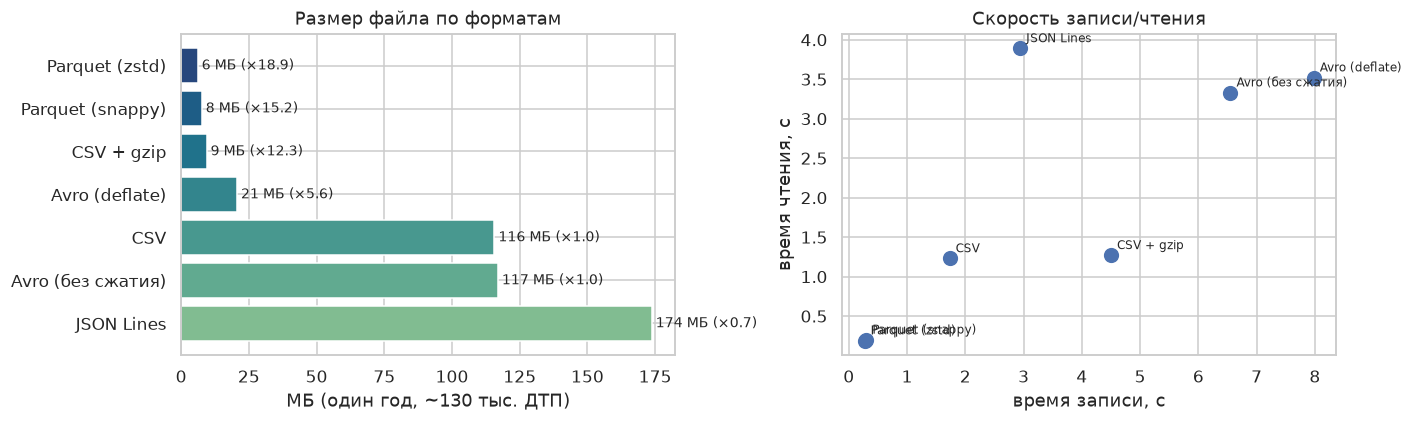

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = fmt.sort_values("байт", ascending=False)
axes[0].barh(order["формат"], order["байт"] / 2**20, color=sns.color_palette("crest", len(order)))
axes[0].set_xlabel("МБ (один год, ~130 тыс. ДТП)"); axes[0].set_title("Размер файла по форматам")
for i, (v, r) in enumerate(zip(order["байт"] / 2**20, order["сжатие vs CSV"])):
    axes[0].text(v, i, f" {v:.0f} МБ (×{r})", va="center", fontsize=9)
axes[1].scatter(fmt["запись_с"], fmt["чтение_с"], s=80)
for _, r in fmt.iterrows():
    axes[1].annotate(r["формат"], (r["запись_с"], r["чтение_с"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("время записи, с"); axes[1].set_ylabel("время чтения, с"); axes[1].set_title("Скорость записи/чтения")
plt.tight_layout(); plt.show()

del csv_df, recs; gc.collect();

Parquet ожидаемо выиграл по всем фронтам.

### 1.4. Рост объёма

In [ ]:
daily_counts = acc.set_index("dt").resample("D").size()
last_year = daily_counts.loc[str(year_full)]
events_per_day = last_year.mean()
print(f"Среднее ДТП в день ({year_full}): {events_per_day:.0f}; мин {last_year.min()}, макс {last_year.max()}")

rows_acc = clean_stats["accidents"]["rows"]
bytes_per_acc = {
    "raw JSON (несжатый)": raw_uncompressed / rows_acc,
    "raw json.zst": manifest["bytes"].sum() / rows_acc,
    "clean Parquet (3 табл.)": sum(s["parquet"] for s in clean_stats.values()) / rows_acc,
    "CSV (оценка)": fmt
                    .loc[fmt["формат"] == "CSV", "байт/строку"].iloc[0]
                    * sum(s["rows"] for s in clean_stats.values()) / rows_acc,
}
pred_days = sorted((DATA_DIR / "predictions/forecast").glob("day=*"))
pred_per_day = np.mean([dir_size(p)[0] for p in pred_days]) if pred_days else 0

growth = pd.DataFrame({"байт на 1 ДТП": bytes_per_acc})
growth["прирост в день"] = growth["байт на 1 ДТП"] * events_per_day
growth.loc["predictions (1 запуск/день)"] = [np.nan, pred_per_day]
growth["прирост в год"] = growth["прирост в день"] * 365
current = {
    "raw JSON (несжатый)": raw_uncompressed,
    "raw json.zst": manifest["bytes"].sum(),
    "clean Parquet (3 табл.)": sum(s["parquet"] for s in clean_stats.values()),
    "CSV (оценка)": bytes_per_acc["CSV (оценка)"] * rows_acc,
    "predictions (1 запуск/день)": dir_size(DATA_DIR / "predictions")[0],
}
growth["сейчас"] = pd.Series(current)
growth["мес. до 1 ТБ"] = ((TB - growth["сейчас"]) / (growth["прирост в день"] * 30.4)).round(0)
display(growth.assign(**{c: growth[c].map(lambda v: human(v) if pd.notna(v) else "-")
                         for c in ["прирост в день", "прирост в год", "сейчас"]}))

Среднее ДТП в день (2025): 353; мин 194, макс 515


,байт на 1 ДТП,прирост в день,прирост в год,сейчас,мес. до 1 ТБ
raw JSON (несжатый),3140.588368,1.1 МБ,385.7 МБ,5.1 ГБ,32482.0
raw json.zst,132.672134,45.7 КБ,16.3 МБ,218.9 МБ,772557.0
clean Parquet (3 табл.),96.358667,33.2 КБ,11.8 МБ,159.0 МБ,1063762.0
CSV (оценка),4816.233156,1.6 МБ,591.5 МБ,7.8 ГБ,21125.0
predictions (1 запуск/день),NaN,73.0 МБ,26.0 ГБ,73.0 МБ,472.0


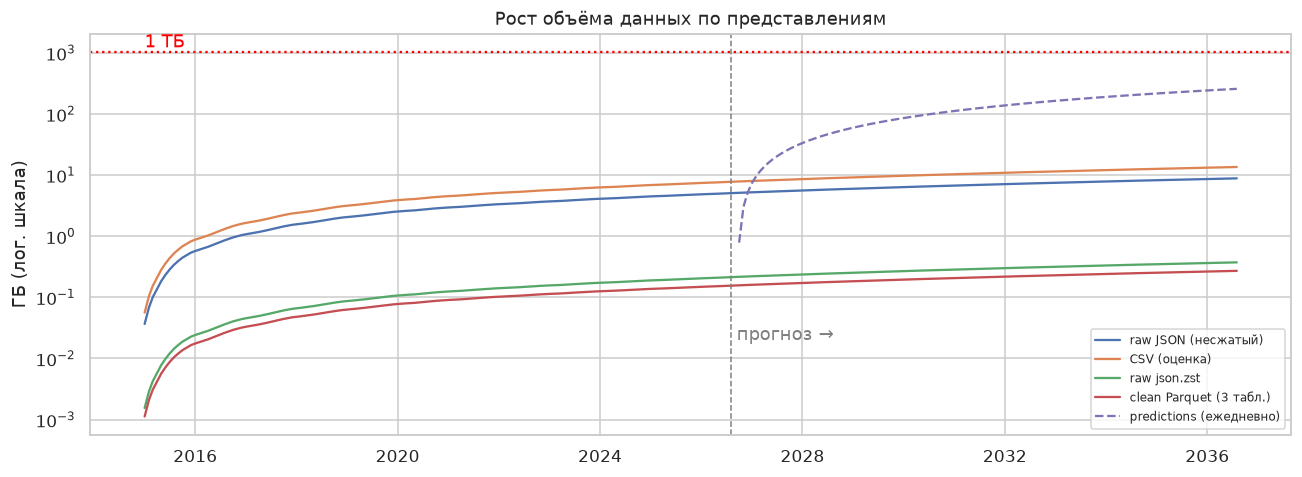

In [88]:
# накопленный объём + прогноз на 10 лет
monthly_acc = acc.set_index("dt").resample("MS").size().cumsum()
future_idx = pd.date_range(monthly_acc.index[-1] + pd.offsets.MonthBegin(), periods=120, freq="MS")
future_cum = monthly_acc.iloc[-1] + np.arange(1, 121) * events_per_day * 30.4
cum = pd.concat([monthly_acc, pd.Series(future_cum, index=future_idx)])

fig, ax = plt.subplots(figsize=(12, 4.5))
for name in ["raw JSON (несжатый)", "CSV (оценка)", "raw json.zst", "clean Parquet (3 табл.)"]:
    ax.plot(cum.index, cum.values * bytes_per_acc[name] / GB, label=name)
start = pd.Timestamp(pred_days[0].name.split("=")[1]) if pred_days else cum.index[-121]
p_idx = cum.index[cum.index >= start]
ax.plot(p_idx, ((p_idx - start).days + 1) * pred_per_day / GB, "--", label="predictions (ежедневно)")
ax.axhline(1024, color="red", ls=":", lw=1.5); ax.text(cum.index[0], 1024 * 1.2, "1 ТБ", color="red")
ax.axvline(monthly_acc.index[-1], color="grey", ls="--", lw=1); ax.text(monthly_acc.index[-1], 0.02, " прогноз →", color="grey")
ax.set_yscale("log"); ax.set_ylabel("ГБ (лог. шкала)"); ax.set_title("Рост объёма данных по представлениям")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

In [89]:
# во сколько раз должен вырасти поток для 1 ТБ/год
for name in ["clean Parquet (3 табл.)", "raw JSON (несжатый)"]:
    need = TB / (bytes_per_acc[name] * 365)
    print(f"{name:26s}: для 1 ТБ/год нужно ≈ {need:,.0f} событий/день  (сейчас {events_per_day:.0f}, т. е. ×{need/events_per_day:,.0f})")
print(f"predictions: 1 ТБ наберётся за {TB / pred_per_day / 365:.1f} лет при одном запуске в день")

clean Parquet (3 табл.)   : для 1 ТБ/год нужно ≈ 31,261,958 событий/день  (сейчас 353, т. е. ×88,612)
raw JSON (несжатый)       : для 1 ТБ/год нужно ≈ 959,171 событий/день  (сейчас 353, т. е. ×2,719)
predictions: 1 ТБ наберётся за 39.3 лет при одном запуске в день


До терабайта при таком потоке нужно тысячи лет, быстрее всего растут только прогнозы.

### 1.5. Горячие и холодные данные

In [90]:
tiers = pd.DataFrame([
    ["clean accidents/participants/vehicles, последние 3 года", "горячие (Standard)",
     "ежедневный пересчёт признаков, дообучение модели, дашборды"],
    ["features (train/valid/test)", "горячие (Standard)", "обучение и backtest; пересоздаются при изменении признаков"],
    ["predictions за последние 90 дней", "горячие (Standard)", "сравнение прогноз/факт, мониторинг качества"],
    ["clean старше 3 лет", "тёплые (Cold)", "переобучение с длинной историей раз в квартал"],
    ["raw json.zst (весь архив)", "холодные (Ice)", "только для перепроцессинга при изменении парсера; воспроизводимость"],
    ["predictions старше 90 дней", "холодные (Ice) / удаление", "аудит; можно хранить только агрегаты"],
], columns=["данные", "уровень", "обоснование"])
display(tiers)

,данные,уровень,обоснование
0,"clean accidents/participants/vehicles, последние 3 года",горячие (Standard),"ежедневный пересчёт признаков, дообучение модели, дашборды"
1,features (train/valid/test),горячие (Standard),обучение и backtest; пересоздаются при изменении признаков
2,predictions за последние 90 дней,горячие (Standard),"сравнение прогноз/факт, мониторинг качества"
3,clean старше 3 лет,тёплые (Cold),переобучение с длинной историей раз в квартал
4,raw json.zst (весь архив),холодные (Ice),только для перепроцессинга при изменении парсера; воспроизводимость
5,predictions старше 90 дней,холодные (Ice) / удаление,аудит; можно хранить только агрегаты


### 1.6. Стоимость хранения

Цену стандартного хранения взял из документации Yandex Object Storage.

In [91]:
# стоимость хранения, Руб/ГБ в месяц
PRICE = {"standard": 2.376, "cold": 1.2, "ice": 0.6}

def yearly_cost(gb: float, cls: str, free_gb: float = 0.0) -> float:
    return max(gb - free_gb, 0) * PRICE[cls] * 12

one_year_parquet_gb = bytes_per_acc["clean Parquet (3 табл.)"] * events_per_day * 365 / GB
all_parquet_gb = current["clean Parquet (3 табл.)"] / GB
raw_gb = current["raw json.zst"] / GB
pred_year_gb = pred_per_day * 365 / GB

cost = pd.DataFrame([
    ["1 год данных в Parquet", one_year_parquet_gb, "standard"],
    ["вся история clean в Parquet", all_parquet_gb, "standard"],
    ["raw-архив json.zst", raw_gb, "ice"],
    ["predictions за год (ежедневно)", pred_year_gb, "standard"],
    ["predictions за год (ежедневно)", pred_year_gb, "cold"],
], columns=["что храним", "ГБ", "класс"])
cost["Руб в год"] = [yearly_cost(g, c) for g, c in zip(cost["ГБ"], cost["класс"])]
cost["ГБ"] = cost["ГБ"].round(3)
cost["Руб в год"] = cost["Руб в год"].round(2)
display(cost)
print(f"Итого для рекомендуемой схемы (clean+raw+predictions в cold): "
      f"{cost['Руб в год'].iloc[[1, 2, 4]].sum():,.0f} Руб/год")

,что храним,ГБ,класс,Руб в год
0,1 год данных в Parquet,0.012,standard,0.33
1,вся история clean в Parquet,0.155,standard,4.43
2,raw-архив json.zst,0.214,ice,1.54
3,predictions за год (ежедневно),26.033,standard,742.25
4,predictions за год (ежедневно),26.033,cold,374.87


Итого для рекомендуемой схемы (clean+raw+predictions в cold): 381 Руб/год


Получилось несколько сотен рублей в год, то есть хранение почти бесплатное.

### 1.7. Когда переходить с pandas на Spark

Считал, что pandas нужно примерно в 5 раз больше памяти, чем весят данные, а машина - 32 ГБ.

In [92]:
# запас pandas на ВМ 32 ГБ
RAM_GB = 32
OVERHEAD = 5
pandas_limit = RAM_GB * GB / OVERHEAD
per_day_pandas = pandas_per_row * events_per_day
years_left = (pandas_limit - pandas_total) / (per_day_pandas * 365)
print(f"Сейчас весь период в pandas: {human(pandas_total)}. Комфортный предел: {human(pandas_limit)}")
print(f"Запас по росту: ≈ {years_left:.0f} лет при текущем потоке")
print(f"Порог по числу строк accidents ≈ {pandas_limit / pandas_per_row / 1e6:.1f} млн ДТП "
      f"(сейчас {rows_acc/1e6:.2f} млн)")

Сейчас весь период в pandas: 2.4 ГБ. Комфортный предел: 6.4 ГБ
Запас по росту: ≈ 22 лет при текущем потоке
Порог по числу строк accidents ≈ 4.6 млн ДТП (сейчас 1.73 млн)


**Вывод.** По объёму это точно не Big Data: на диске 616 МБ, даже весь сырой JSON без сжатия - около 5 ГБ.
Parquet получился в 19 раз компактнее CSV, так что храню всё в нём. Данные растут на ~12 МБ в год, а вот прогнозы
набегают по 26 ГБ в год, поэтому их будем держать только 90 дней. Spark тут не нужен - pandas хватит ещё лет на 20.

## Часть 2. Velocity

### 2.1. Частота поступления

In [93]:
# среднее, пик и CV по окнам
ts = acc.set_index("dt").sort_index()
period_sec = (ts.index.max() - ts.index.min()).total_seconds()

per5 = ts.resample("5min").size()
per_hour = ts.resample("h").size()
per_day = ts.resample("D").size()
per_month = ts.resample("ME").size()

velocity = pd.DataFrame({
    "окно": ["5 мин", "1 час", "1 сутки", "1 месяц"],
    "среднее": [per5.mean(), per_hour.mean(), per_day.mean(), per_month.mean()],
    "максимум": [per5.max(), per_hour.max(), per_day.max(), per_month.max()],
    "коэффициент вариации": [per5.std() / per5.mean(), per_hour.std() / per_hour.mean(), per_day.std() / per_day.mean(), per_month.std() / per_month.mean()],
}).round(3)
display(velocity)
print(f"Средняя скорость: {len(acc) / period_sec:.4f} событий/с  (≈ {len(acc) / period_sec * 86400:.0f} в сутки)")
print(f"Пик за 5 минут: {per5.max()} ДТП = {per5.max() / 300:.3f} событий/с, окно: {per5.idxmax()}")
print(f"Пик/среднее (5 мин): ×{per5.max() / per5.mean():.1f}")

,окно,среднее,максимум,коэффициент вариации
0,5 мин,1.410,21,1.172
1,1 час,16.920,82,0.630
2,1 сутки,406.072,763,0.249
3,1 месяц,12359.086,18768,0.233


Средняя скорость: 0.0047 событий/с  (≈ 406 в сутки)
Пик за 5 минут: 21 ДТП = 0.070 событий/с, окно: 2015-10-09 19:00:00
Пик/среднее (5 мин): ×14.9


В среднем выходит около 400 ДТП в сутки. Пик в 21 ДТП за 5 минут немного завышен - время в карточках часто округляют.

### 2.2. Распределение во времени

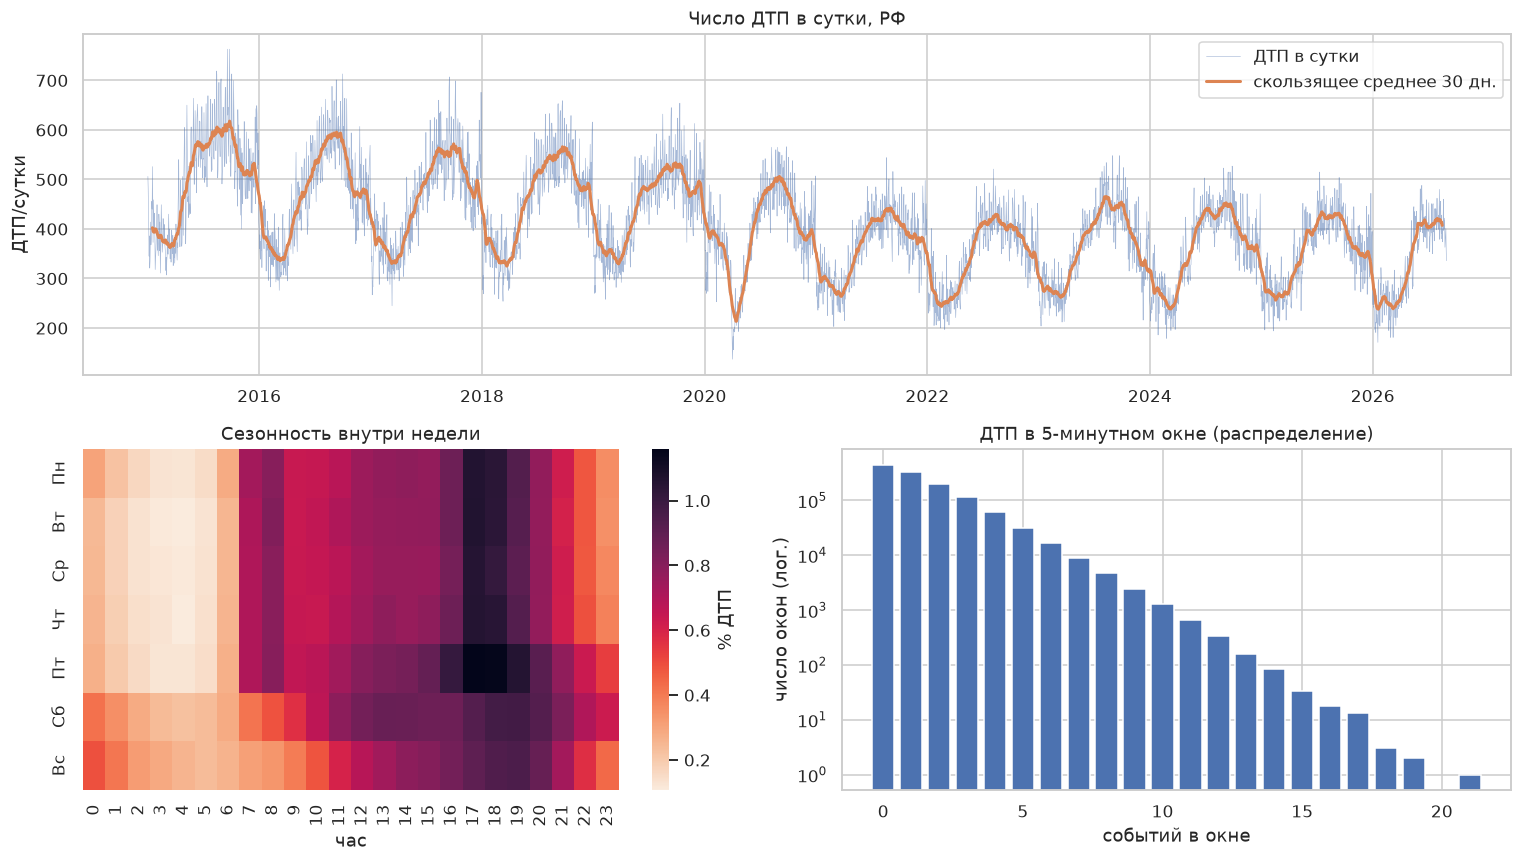

In [94]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

ax = fig.add_subplot(gs[0, :])
ax.plot(per_day.index, per_day.values, lw=0.4, alpha=0.5, label="ДТП в сутки")
ax.plot(per_day.index, per_day.rolling(30, center=True).mean(), lw=2, label="скользящее среднее 30 дн.")
ax.set_title("Число ДТП в сутки, РФ"); ax.legend(); ax.set_ylabel("ДТП/сутки")

ax = fig.add_subplot(gs[1, 0])
heat = acc.pivot_table(index="weekday", columns="hour", values="accident_id", aggfunc="count")
heat.index = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
sns.heatmap(heat / heat.values.sum() * 100, cmap="rocket_r", ax=ax, cbar_kws={"label": "% ДТП"})
ax.set_title("Сезонность внутри недели"); ax.set_xlabel("час"); ax.set_ylabel("")

ax = fig.add_subplot(gs[1, 1])
vc = per5.value_counts().sort_index()
ax.bar(vc.index, vc.values); ax.set_yscale("log")
ax.set_title("ДТП в 5-минутном окне (распределение)"); ax.set_xlabel("событий в окне"); ax.set_ylabel("число окон (лог.)")
plt.tight_layout(); plt.show()

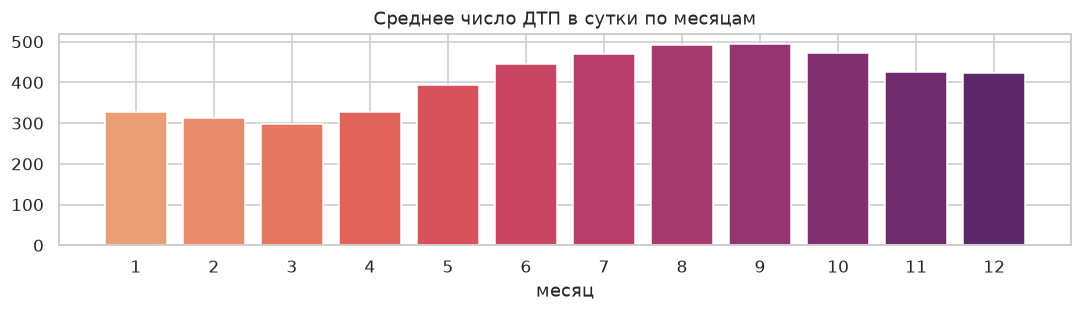

Летний пик \ зимний минимум: ×1.66


In [95]:
# сезонность по месяцам
monthly_profile = per_day.groupby(per_day.index.month).mean()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(monthly_profile.index, monthly_profile.values, color=sns.color_palette("flare", 12))
ax.set_xticks(range(1, 13)); ax.set_title("Среднее число ДТП в сутки по месяцам"); ax.set_xlabel("месяц")
plt.tight_layout(); plt.show()
print(f"Летний пик \ зимний минимум: ×{monthly_profile.max() / monthly_profile.min():.2f}")

Видно, что летом аварий примерно в полтора раза больше, чем зимой, а хуже всего будни с 17 до 19. В 2020 году заметен провал из-за короны.


### 2.3. Как быстро доходят данные

ГИБДД выкладывает карточки раз в месяц и с опозданием, а предварительные карточки потом ещё и правит.

In [96]:
# лаг источника и скорость загрузчика
status_dict = json.load(open(DATA_DIR / "dict/concentration_status.json", encoding="utf-8"))
print("Статусы карточек:", [s["rows_name"] for s in status_dict])

run_files = sorted((DATA_DIR / "predictions/forecast").glob("day=*/run.json"))
run = json.load(open(run_files[-1], encoding="utf-8"))
data_until = pd.Timestamp(run["data_until"])
predicted_at = pd.Timestamp(run["predicted_at"]).tz_localize(None)
source_lag = predicted_at - (data_until + pd.Timedelta(days=1))
print(f"Данные есть по {data_until.date()}, прогноз построен {predicted_at:%Y-%m-%d %H:%M} UTC "
      f"-> лаг источника ≈ {source_lag.days} сут.")
print(f"Время работы инференса: {run['seconds']:.1f} с")

m = manifest_all.copy()
m["fetched_at"] = pd.to_datetime(m["fetched_at"])
crawl_sec = (m["fetched_at"].max() - m["fetched_at"].min()).total_seconds()
print(f"Полная загрузка истории: {len(m):,} запросов за {crawl_sec/60:.0f} мин "
      f"-> {len(m)/crawl_sec:.1f} запросов/с, {m['bytes'].sum()/crawl_sec/1024:.0f} КБ/с (сжатых), "
      f"{m['cards'].sum()/crawl_sec:.0f} карточек/с")
print("Распределение числа попыток (ретраи из-за ошибок API):")
display(m["attempts"].describe(percentiles=[.5, .9, .99]).round(1).to_frame().T)

Статусы карточек: ['Сформированные', 'Предварительные']
Данные есть по 2026-08-31, прогноз построен 2026-09-21 08:21 UTC -> лаг источника ≈ 20 сут.
Время работы инференса: 21.2 с
Полная загрузка истории: 13,228 запросов за 42 мин -> 5.3 запросов/с, 92 КБ/с (сжатых), 711 карточек/с
Распределение числа попыток (ретраи из-за ошибок API):


,count,mean,std,min,50%,90%,99%,max
attempts,13228.0,3.2,9.9,1.0,2.0,4.0,70.0,124.0


### 2.4. Задержка при разных режимах обработки

Посчитал задержку как отставание источника + половина интервала запуска + время обработки.

In [97]:
def to_cell(lat, lon, size_km=1.0):
    y = np.floor(lat * 111.0 / size_km).astype("Int64")
    x = np.floor(lon * 111.0 * np.cos(np.radians(lat)) / size_km).astype("Int64")
    return y.astype(str) + "_" + x.astype(str)

t0 = time.perf_counter()
geo = acc.dropna(subset=["lat", "lon"])
cells = to_cell(geo["lat"], geo["lon"])
grid_day = (geo.assign(cell=cells, day=geo["dt"].dt.floor("D"))
               .groupby(["cell", "day"], observed=True)
               .agg(n=("accident_id", "size"), dead=("dead_n", "sum"), injured=("injured_n", "sum")))
t_features = time.perf_counter() - t0
print(f"Агрегация {len(geo):,} ДТП -> {len(grid_day):,} строк «ячейка×сутки» за {t_features:.1f} с (1 процесс)")

t_processing = t_features + run["seconds"]
lag_s = source_lag.total_seconds()
modes = pd.DataFrame([
    ["Batch раз в час", 3600, t_processing],
    ["Micro-batch каждые 5 мин", 300, t_processing],
    ["True streaming", 0, 0.05],
], columns=["режим", "интервал_с", "обработка_с"])
modes["задержка без учёта источника"] = (modes["интервал_с"] / 2 + modes["обработка_с"]).map(
    lambda s: f"{s/60:.1f} мин" if s >= 60 else f"{s*1000:.0f} мс")
modes["сквозная задержка (с лагом источника)"] = ((lag_s + modes["интервал_с"] / 2 + modes["обработка_с"]) / 86400).map(
    lambda d: f"{d:.2f} сут")
display(modes)

Агрегация 1,714,996 ДТП -> 1,688,365 строк «ячейка×сутки» за 1.5 с (1 процесс)


,режим,интервал_с,обработка_с,задержка без учёта источника,сквозная задержка (с лагом источника)
0,Batch раз в час,3600,22.783843,30.4 мин,20.37 сут
1,Micro-batch каждые 5 мин,300,22.783843,2.9 мин,20.35 сут
2,True streaming,0,0.050000,50 мс,20.35 сут


Получилось, что режим вообще ни на что не влияет - всё упирается в отставание источника почти на три недели.

### 2.5. Что потеряется при сбое на 30 минут

In [98]:
per30 = ts.resample("30min").size()
print(f"В среднем за 30 минут происходит {per30.mean():.1f} ДТП, в пиковое 30-минутное окно - {per30.max()}")
print(f"В байтах: {per30.mean() * bytes_per_acc['raw JSON (несжатый)'] / 1024:.0f} КБ сырого JSON в среднем, "
      f"{per30.max() * bytes_per_acc['raw JSON (несжатый)'] / 1024:.0f} КБ в пике")

partial = manifest[manifest["status"] == "partial"]
print(f"\nФактически в манифесте {len(partial)} выгрузок со статусом 'partial' (часть часов не отдана API) - "
      f"они и есть «потери», которые закрываются повторной загрузкой.")

В среднем за 30 минут происходит 8.5 ДТП, в пиковое 30-минутное окно - 54
В байтах: 26 КБ сырого JSON в среднем, 166 КБ в пике

Фактически в манифесте 200 выгрузок со статусом 'partial' (часть часов не отдана API) - они и есть «потери», которые закрываются повторной загрузкой.


### 2.6. Допустимая задержка и ресурсы

Раньше всех прогноз нужен Камчатке: 06:00 там - это 18:00 UTC накануне, а прогноз погоды появляется примерно к полудню.
Половину этого окна оставил на перезапуски, так что на весь пайплайн у меня **3 часа**.

In [99]:
X_BUDGET_S = 3 * 3600
single_core_s = t_processing
cores_needed = math.ceil(single_core_s / (X_BUDGET_S * 0.5))
print(f"Пайплайн на 1 ядре: {single_core_s:.0f} с; бюджет: {X_BUDGET_S} с -> нужно ядер: {cores_needed}")

sample = geo.sample(20000, random_state=SEED)
counter = Counter()
t0 = time.perf_counter()
for la, lo in zip(sample["lat"].values, sample["lon"].values):
    key = (int(la * 111.0), int(lo * 111.0 * math.cos(math.radians(la))))
    counter[key] += 1
service_time = (time.perf_counter() - t0) / len(sample)

peak_rate = per5.max() / 300
for mult in [1, 1000, 100000]:
    rate = peak_rate * mult
    need = rate * service_time / 0.5
    print(f"Пик × {mult}: λ = {rate:10f} соб/с -> нужно {max(1, math.ceil(need))} ядро(а) "
          f"(S = {service_time*1e6:.1f} мкс/событие, задержка << 50 мс)")

Пайплайн на 1 ядре: 23 с; бюджет: 10800 с -> нужно ядер: 1
Пик × 1: λ =   0.070000 соб/с -> нужно 1 ядро(а) (S = 0.8 мкс/событие, задержка << 50 мс)
Пик × 1000: λ =  70.000000 соб/с -> нужно 1 ядро(а) (S = 0.8 мкс/событие, задержка << 50 мс)
Пик × 100000: λ = 7000.000000 соб/с -> нужно 1 ядро(а) (S = 0.8 мкс/событие, задержка << 50 мс)


**Вывод.** Поток совсем маленький, и узкое место не в обработке, а в источнике. Стриминг здесь ничего не даст,
поэтому решил считать всё раз в сутки и раз в месяц перекачивать последние месяцы. Весь пайплайн отрабатывает
за ~20 секунд на одном ядре, так что Kafka и Flink тут не нужны.

## Часть 3. Variety

### 3.1. Типы полей

тип,гео,дата/время,категориальный,списковый,текстовый,числовой
таблица,,,,,,
accidents,2,3,9,5,6,11
participants,0,0,9,2,1,1
vehicles,0,0,7,0,2,1


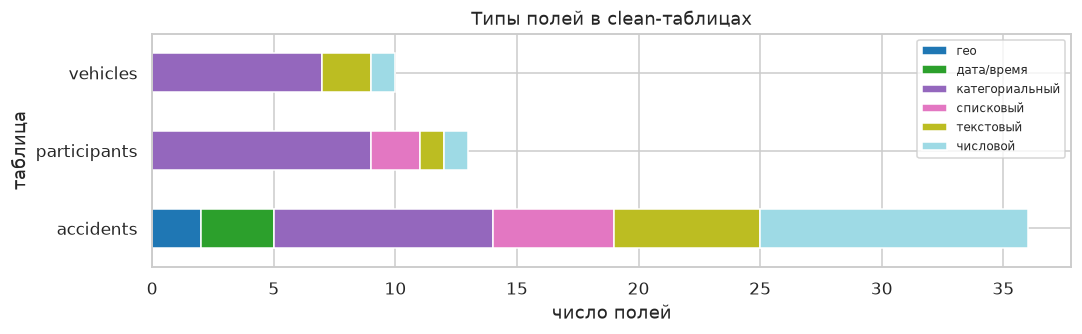

In [100]:
tables = {
    "accidents": acc25,
    "participants": pd.read_parquet(DATA_DIR / f"clean/participants/year={year_full}/part.parquet"),
    "vehicles": pd.read_parquet(DATA_DIR / f"clean/vehicles/year={year_full}/part.parquet"),
}

def semantic_type(s: pd.Series, name: str) -> str:
    if name in ("lat", "lon"):
        return "гео"
    if pd.api.types.is_datetime64_any_dtype(s) or name in ("dt_date", "dt_time"):
        return "дата/время"
    if pd.api.types.is_numeric_dtype(s):
        return "числовой"
    sample = s.dropna().head(1000)
    if len(sample) and sample.map(lambda v: isinstance(v, (list, np.ndarray))).any():
        return "списковый"
    return "категориальный" if s.nunique(dropna=True) < 1000 else "текстовый"

rows = []
for tname, df in tables.items():
    for c in df.columns:
        st = semantic_type(df[c], c)
        nun = df[c].map(lambda v: tuple(v) if isinstance(v, (list, np.ndarray)) else v).nunique() if st == "списковый" \
              else df[c].nunique()
        rows.append((tname, c, str(df[c].dtype), st, nun, round(df[c].isna().mean() * 100, 1)))
schema_df = pd.DataFrame(rows, columns=["таблица", "поле", "dtype", "тип", "уникальных", "пропусков, %"])
type_stats = schema_df.pivot_table(index="таблица", columns="тип", values="поле", aggfunc="count", fill_value=0)
display(type_stats)

fig, ax = plt.subplots(figsize=(10, 3.2))
type_stats.plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
ax.set_xlabel("число полей"); ax.set_title("Типы полей в clean-таблицах"); ax.legend(bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); plt.show()

In [101]:
schema_df[schema_df["таблица"] == "accidents"].reset_index(drop=True)

,таблица,поле,dtype,тип,уникальных,"пропусков, %"
0,accidents,accident_id,str,текстовый,128771,0.0
1,accidents,reg_code,int64,числовой,86,0.0
2,accidents,reg_name,str,категориальный,86,0.0
3,accidents,empt_number,str,текстовый,128753,0.0
4,accidents,dt,datetime64[us],дата/время,78986,0.0
5,accidents,dt_date,object,дата/время,365,0.0
6,accidents,dt_time,object,дата/время,1438,0.0
7,accidents,year,int64,числовой,1,0.0
8,accidents,month,int64,числовой,12,0.0
9,accidents,hour,int64,числовой,24,0.0


### 3.2. Что внутри сырого JSON

Сырой ответ API - это матрёшка: карточки ДТП лежат глубоко внутри, а в каждой карточке ещё машины и участники.

In [102]:
# пути и глубина вложенности в сыром JSON
def read_raw(path) -> dict:
    return json.loads(dctx.decompress(open(path, "rb").read(), max_output_size=2**31))

def cards_of(doc) -> list:
    return doc["results"]["region_list"][0]["pok_list"][0]["result"][0]["dtpcardlist"]["info_dtp"]

def walk_paths(obj, prefix="", depth=0, acc_paths=None):
    if acc_paths is None:
        acc_paths = Counter()
    if isinstance(obj, dict):
        for k, v in obj.items():
            walk_paths(v, f"{prefix}.{k}" if prefix else k, depth + 1, acc_paths)
    elif isinstance(obj, list):
        for v in obj:
            walk_paths(v, prefix + "[]", depth + 1, acc_paths)
    else:
        acc_paths[(prefix, depth)] += 1
    return acc_paths

biggest_raw = max(raw_files, key=os.path.getsize)
raw_doc = read_raw(biggest_raw)
raw_cards = cards_of(raw_doc)
paths = Counter()
for c in raw_cards:
    walk_paths(c, acc_paths=paths)
paths_df = pd.DataFrame([(p, d, n) for (p, d), n in paths.items()], columns=["путь", "глубина", "значений"])
print(f"Файл: {Path(biggest_raw).relative_to(DATA_DIR)}; карточек: {len(raw_cards)}")
print(f"Уникальных путей к полям: {paths_df['путь'].nunique()}, максимальная глубина: {paths_df['глубина'].max()}")
print(f"Колонок в clean-таблицах: {sum(df.shape[1] for df in tables.values())} (3 таблицы вместо 1 вложенного документа)")
paths_df.sort_values(["глубина", "путь"]).groupby("глубина").head(4)

Файл: raw/year=2015/month=08/reg=1145.json.zst; карточек: 973
Уникальных путей к полям: 60, максимальная глубина: 6
Колонок в clean-таблицах: 59 (3 таблицы вместо 1 вложенного документа)


,путь,глубина,значений
4,coord_l,1,973
3,coord_w,1,973
1,date_dtp,1,973
11,district,1,973
28,dor_usl.chom,2,973
27,dor_usl.osv,2,973
26,dor_usl.s_pch,2,973
24,dor_usl.factor[],3,980
23,dor_usl.ndu[],3,1024
22,dor_usl.obj_dtp[],3,1505


In [103]:
example = dict(raw_cards[0]); example["ts_info"] = example["ts_info"][:1]
print(json.dumps(example, ensure_ascii=False, indent=1)[:1800], "...")

{
 "empt_number": "",
 "date_dtp": "31.08.2015",
 "time": "18:50",
 "coord_w": "55.000000",
 "coord_l": "37.000000",
 "dtpv": "Столкновение",
 "k_ts": 2,
 "k_uch": 3,
 "pog": 0,
 "ran": 1,
 "s_dtp": "070",
 "district": "Восточное Дегунино",
 "house": "108",
 "km": "0",
 "m": "0",
 "np": "г Москва",
 "street": "ш Дмитровское",
 "dor": "",
 "dor_z": "Не указано",
 "dor_k": "",
 "k_ul": "Магистральные улицы общегородского значения",
 "dor_usl": {
  "sdor": [
   "Перегон (нет объектов на месте ДТП)",
   "Выезд с прилегающей территории"
  ],
  "obj_dtp": [
   "Производственное предприятие"
  ],
  "ndu": [
   "Отсутствие, плохая различимость горизонтальной разметки проезжей части",
   "Отсутствие дорожных знаков в необходимых местах"
  ],
  "factor": [
   "Сведения отсутствуют"
  ],
  "spog": [
   "Пасмурно"
  ],
  "s_pch": "Сухое",
  "osv": "В темное время суток, освещение включено",
  "chom": "Движение частично перекрыто"
 },
 "ts_info": [
  {
   "n_ts": "1",
   "ts_s": "Нет",
   "t_ts": "

### 3.3. Проблемы с разнообразием

Пока разбирал данные, собрал вот такие проблемы:

In [104]:
# примеры проблем разнообразия
problems = []

problems.append(("формат даты/времени (raw)", f"date_dtp='{raw_cards[0]['date_dtp']}', time='{raw_cards[0]['time']}'",
                 "парсинг с явным форматом %d.%m.%Y %H:%M"))

num_as_str = {k: raw_cards[0][k] for k in ["coord_w", "coord_l", "km", "m"]}
problems.append(("числа хранятся строками (raw)", str(num_as_str), "приведение типов + валидация диапазонов"))

empty_share = {k: np.mean([c.get(k, None) == "" for c in raw_cards]) for k in ["dor", "dor_k", "empt_number", "house", "street"]}
problems.append(("пустая строка вместо null (raw)", {k: f"{v:.0%}" for k, v in empty_share.items()}, "'' -> NULL"))

alco = Counter(u.get("alco") for c in raw_cards for t in c["ts_info"] for u in t["ts_uch"])
problems.append(("коды с ведущими нулями", f"alco: {dict(alco.most_common(3))}; s_dtp='{raw_cards[0]['s_dtp']}'",
                 "хранить как строку-код, не как число"))

d = acc[["reg_name", "district", "year"]].dropna()
upper = d["district"].str.isupper()
problems.append(("разный регистр в district", f"'{d.loc[upper, 'district'].iloc[0]}' vs '{d.loc[~upper, 'district'].iloc[0]}'; "
                 f"ЗАГЛАВНЫМИ {upper.mean():.0%} записей", "нормализация регистра + справочник ОКТМО"))

sem_null = Counter(v for c in raw_cards for k in ["factor", "ndu"] for v in c["dor_usl"].get(k, [])
                   if v in ("Сведения отсутствуют", "Не установлены"))
problems.append(("пустые значения внутри списков (raw)", dict(sem_null), "маппинг в пустой список"))

problems.append(("конфликт схем партиций", "year: int64 в файле vs dictionary<int32> из имени каталога",
                 "не дублировать партиционную колонку в файле / явная схема"))

mpov = ""
for f in raw_files:
    mpov = next((t["m_pov"] for c in cards_of(read_raw(f)) for t in c["ts_info"] if "|" in t.get("m_pov", "")), "")
    if mpov:
        break
problems.append(("несколько значений в одной строке", f"m_pov='{mpov[:90]}…'", "split -> список"))

pd.DataFrame(problems, columns=["проблема", "пример", "обработка"])

,проблема,пример,обработка
0,формат даты/времени (raw),"date_dtp='31.08.2015', time='18:50'",парсинг с явным форматом %d.%m.%Y %H:%M
1,числа хранятся строками (raw),"{'coord_w': '55.000000', 'coord_l': '37.000000', 'km': '0', 'm': '0'}",приведение типов + валидация диапазонов
2,пустая строка вместо null (raw),"{'dor': '85%', 'dor_k': '68%', 'empt_number': '100%', 'house': '13%', 'stree...",'' -> NULL
3,коды с ведущими нулями,"alco: {'': 1683, '00': 289, '02': 7}; s_dtp='070'","хранить как строку-код, не как число"
4,разный регистр в district,'ЖЕЛЕЗНОДОРОЖНЫЙ' vs 'г. Канск'; ЗАГЛАВНЫМИ 11% записей,нормализация регистра + справочник ОКТМО
5,пустые значения внутри списков (raw),"{'Сведения отсутствуют': 869, 'Не установлены': 805}",маппинг в пустой список
6,конфликт схем партиций,year: int64 в файле vs dictionary<int32> из имени каталога,не дублировать партиционную колонку в файле / явная схема
7,несколько значений в одной строке,"m_pov='Передний правый угол | Передний левый бок (передняя дверь водителя, в...",split -> список


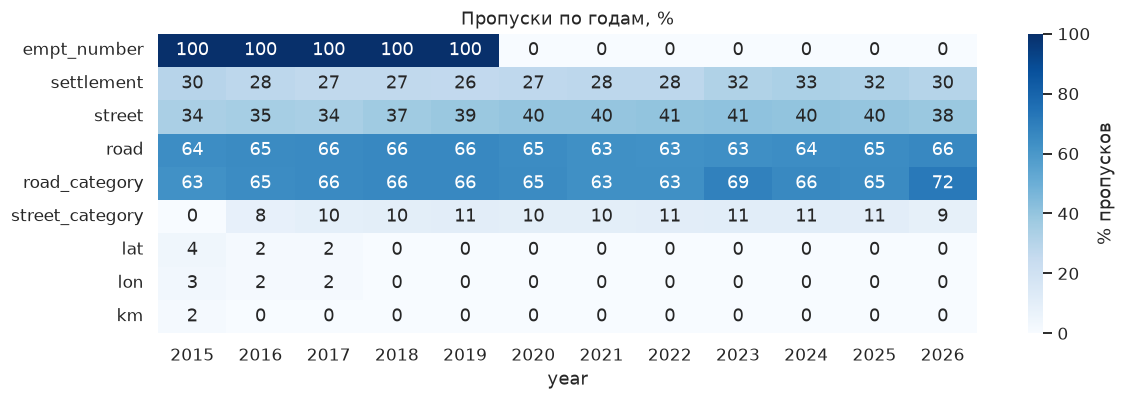

In [105]:
# пропуски по годам
miss_cols = ["empt_number", "settlement", "street", "road", "road_category", "street_category", "lat", "lon", "km"]
miss_by_year = acc.groupby("year")[miss_cols].agg(lambda s: s.isna().mean() * 100)
fig, ax = plt.subplots(figsize=(11, 3.8))
sns.heatmap(miss_by_year.T, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "% пропусков"})
ax.set_title("Пропуски по годам, %"); plt.tight_layout(); plt.show()

По тепловой карте видно, что заполненность полей меняется от года к году, например, номер карточки появился только с 2020-го.

In [106]:
miss_reg = (acc.assign(no_geo=acc["lat"].isna())
               .groupby("reg_name", observed=True)["no_geo"].mean().sort_values(ascending=False).head(8) * 100).round(1)
miss_reg.to_frame("нет координат, %")

,"нет координат, %"
reg_name,
Республика Ингушетия,8.5
гор. Севастополь,5.8
Республика Северная Осетия-Алания,5.2
Республика Дагестан,4.7
Новгородская область,3.9
Тюменская область,3.8
Тамбовская область,3.3
Республика Коми,3.1


### 3.4. Тексты и геоданные

Тексты тут - это адреса и названия дорог, так что NLP не нужен, хватит нормализации.

In [ ]:
# разные написания одних названий; размер multi-hot
text_stats = pd.DataFrame({
    "уникальных": [acc[c].nunique() for c in ["settlement", "street", "road", "district"]],
    "заполнено": [acc[c].notna().sum() for c in ["settlement", "street", "road", "district"]],
}, index=["settlement", "street", "road", "district"])
text_stats["записей на значение"] = (text_stats["заполнено"] / text_stats["уникальных"]).round(1)
display(text_stats)

def norm_text(x: pd.Series) -> pd.Series:
    return (x.str.lower().str.replace(r"[«»\"'.,\-–-()\s]+", " ", regex=True).str.strip())
for col in ["road", "street"]:
    vals = pd.Series(acc[col].dropna().unique())
    keys = norm_text(vals)
    grp = vals.groupby(keys).agg(list)
    multi_var = grp[grp.map(len) > 1]
    print(f"{col}: {len(vals):,} написаний -> {keys.nunique():,} после нормализации "
          f"({len(multi_var):,} групп с разными написаниями)")
ex = multi_var.iloc[multi_var.map(len).argmax()]
print("Пример группы разных написаний одной улицы:", ex[:5])

multi = {c: acc25[c].explode().nunique() for c in list_cols}
print("\nУникальных значений в списковых полях (-> число бинарных признаков):", multi)

,уникальных,заполнено,записей на значение
settlement,28927,1231246,42.6
street,31316,1074616,34.3
road,27249,610653,22.4
district,2534,1730272,682.8


road: 27,249 написаний -> 26,915 после нормализации (326 групп с разными написаниями)
street: 31,316 написаний -> 31,093 после нормализации (210 групп с разными написаниями)
Пример группы разных написаний одной улицы: ['ул Воинов-интернационалистов', 'ул Воинов интернационалистов', 'ул Воинов-Интернационалистов', 'ул Воинов Интернационалистов']

Уникальных значений в списковых полях (-> число бинарных признаков): {'weather': 9, 'uds_elements': 29, 'nearby_objects': 43, 'road_defects': 28, 'factors': 24}


Ячеек ~1×1 км с хотя бы одним ДТП: 342,226; медиана ДТП на ячейку: 1; максимум: 2,573


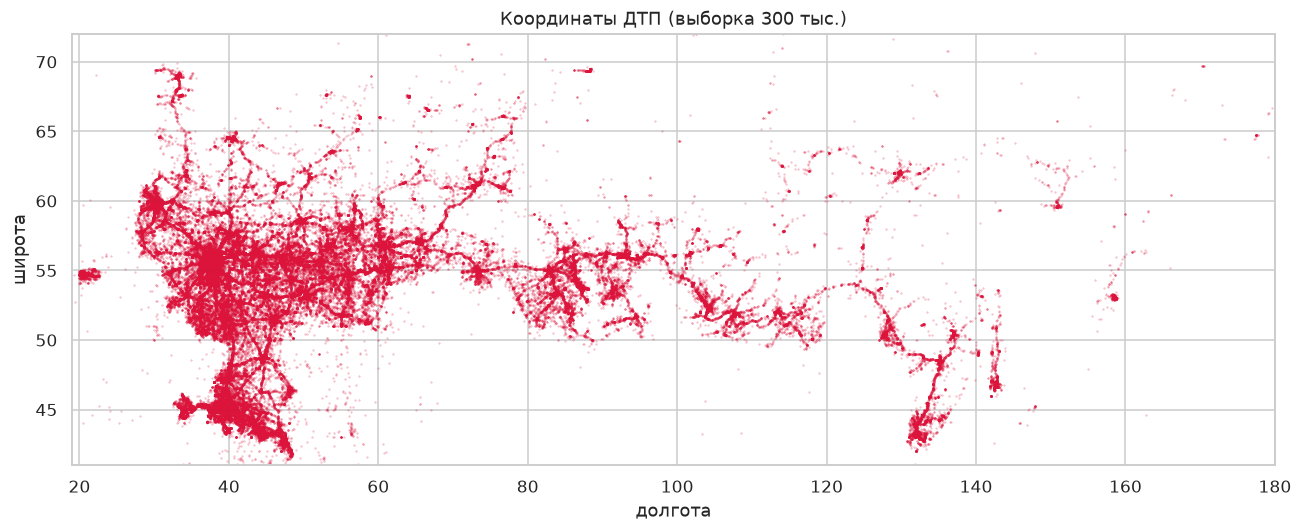

In [108]:
# привязка к сетке ~1 км
cell_counts = cells.value_counts()
print(f"Ячеек ~1×1 км с хотя бы одним ДТП: {len(cell_counts):,}; медиана ДТП на ячейку: {cell_counts.median():.0f}; "
      f"максимум: {cell_counts.max():,}")
fig, ax = plt.subplots(figsize=(12, 5))
sub = geo.sample(300_000, random_state=SEED)
ax.scatter(sub["lon"], sub["lat"], s=0.2, alpha=0.3, c="crimson")
ax.set_xlim(19, 180); ax.set_ylim(41, 72); ax.set_xlabel("долгота"); ax.set_ylabel("широта")
ax.set_title("Координаты ДТП (выборка 300 тыс.)"); plt.tight_layout(); plt.show()

На карте по точкам ДТП прямо видна дорожная сеть страны.

### 3.5. Что можно разложить по таблицам

In [109]:
pd.DataFrame([
    ["скаляры карточки (дата, координаты, счётчики, вид ДТП)", "структурируется полностью", "fact_accident"],
    ["условия (погода, покрытие, освещение)", "категории / multi-hot", "fact_accident + dim"],
    ["ТС и участники (ts_info, ts_uch, uch_info)", "нормализуются в отдельные таблицы", "vehicles, participants"],
    ["списки факторов/нарушений/объектов", "массивы → multi-hot или bridge-таблица", "LIST в Parquet"],
    ["адреса (settlement, street, house)", "частично: нормализация + геокодирование", "текст + ссылка на справочник"],
    ["дороги (road, km, m)", "частично: матчинг со справочником federal_roads", "dim_road"],
    ["исходный JSON ответа API", "хранится как есть (bronze)", "raw/*.json.zst"],
], columns=["данные", "преобразование", "куда"])

,данные,преобразование,куда
0,"скаляры карточки (дата, координаты, счётчики, вид ДТП)",структурируется полностью,fact_accident
1,"условия (погода, покрытие, освещение)",категории / multi-hot,fact_accident + dim
2,"ТС и участники (ts_info, ts_uch, uch_info)",нормализуются в отдельные таблицы,"vehicles, participants"
3,списки факторов/нарушений/объектов,массивы → multi-hot или bridge-таблица,LIST в Parquet
4,"адреса (settlement, street, house)",частично: нормализация + геокодирование,текст + ссылка на справочник
5,"дороги (road, km, m)",частично: матчинг со справочником federal_roads,dim_road
6,исходный JSON ответа API,хранится как есть (bronze),raw/*.json.zst


### 3.6. Как бы я это хранил

Решил хранить по медальонной схеме: сырой JSON как есть в bronze, разобранные таблицы ДТП, участников и машин
в Parquet в silver, а признаки и прогнозы - в gold. Списки оставляю списками, Parquet с ними нормально работает.
И главное, не дублировать year внутри файлов, тогда не будет конфликта, на который я наткнулся в самом начале.

**Вывод.** Данные полуструктурированные: вложенный JSON, который после разбора превращается в три таблицы.
Основная возня с числами и датами в виде строк, пустыми строками вместо null и «Сведения отсутствуют» в роли значения.
Для такого лучше всего подходят Parquet, DuckDB и H3 / GeoPandas для координат.

## Часть 4. Veracity

### 4.1. Метрики качества

In [110]:
# метрики качества
reg_center = acc.groupby("reg_code")[["lat", "lon"]].median()
c_lat = acc["reg_code"].map(reg_center["lat"]); c_lon = acc["reg_code"].map(reg_center["lon"])

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

acc["dist_center_km"] = haversine_km(acc["lat"], acc["lon"], c_lat, c_lon)

reg_p999 = acc.groupby("reg_code")["dist_center_km"].quantile(0.999)
far = acc["dist_center_km"] > acc["reg_code"].map(reg_p999) * 1.5

coord_key = acc["lat"].round(6).astype(str) + "," + acc["lon"].round(6).astype(str)
coord_rep = coord_key.map(coord_key.value_counts())

int_coord = (acc["lat"] % 1 == 0) & (acc["lon"] % 1 == 0)

minute = acc["dt"].dt.minute
checks = {
    "пропуск координат (lat/lon)": acc["lat"].isna() | acc["lon"].isna(),
    "пропуск номера карточки (empt_number)": acc["empt_number"].isna(),
    "дубликат accident_id": acc["accident_id"].duplicated(keep=False),
    "дубль по содержанию (регион+время+точка+вид+ТС+участники)":
        acc.duplicated(["reg_code", "dt", "lat", "lon", "accident_kind", "vehicles_n", "participants_n"], keep=False),
    "нет пострадавших (dead=0 и injured=0)": (acc["dead_n"] == 0) & (acc["injured_n"] == 0),
    "пострадавших больше участников": acc["dead_n"] + acc["injured_n"] > acc["participants_n"],
    "аномально много участников (> 50)": acc["participants_n"] > 50,
    "km > 2500 (длиннее почти любой трассы)": acc["km"] > 2500,
    "m >= 1000 (метры должны быть < 1000)": acc["m"] >= 1000,
    "точка далеко от своего региона": far,
    "одни и те же координаты у > 50 ДТП": coord_rep > 50,
    "координаты - целые градусы (точность ~100 км)": int_coord,
    "время округлено до :00 или :30": minute.isin([0, 30]),
}
quality = pd.DataFrame({"записей": {k: int(v.sum()) for k, v in checks.items()}})
quality["доля, %"] = (quality["записей"] / len(acc) * 100).round(3)
print(f"Ожидаемая доля :00/:30 при равномерном времени: {2/60*100:.1f} %")
display(quality)

Ожидаемая доля :00/:30 при равномерном времени: 3.3 %


,записей,"доля, %"
пропуск координат (lat/lon),15276,0.883
пропуск номера карточки (empt_number),853781,49.344
дубликат accident_id,0,0.000
дубль по содержанию (регион+время+точка+вид+ТС+участники),135,0.008
нет пострадавших (dead=0 и injured=0),1,0.000
пострадавших больше участников,0,0.000
аномально много участников (> 50),14,0.001
km > 2500 (длиннее почти любой трассы),16,0.001
m >= 1000 (метры должны быть < 1000),0,0.000
точка далеко от своего региона,646,0.037


In [111]:
load_quality = pd.DataFrame({
    "показатель": ["пар (регион, месяц) всего", "статус ok", "статус empty (нет ДТП/нет данных)",
                   "статус partial (часть часов не отдана)", "карточек по манифесту", "строк в clean/accidents",
                   "расхождение raw - clean"],
    "значение": [len(manifest), (manifest["status"] == "ok").sum(), (manifest["status"] == "empty").sum(),
                 (manifest["status"] == "partial").sum(), manifest["cards"].sum(), len(acc),
                 manifest["cards"].sum() - len(acc)],
})
display(load_quality)

empty_reg = manifest[manifest["status"] == "empty"].groupby("reg_code").size().sort_values(ascending=False)
reg_names = {int(r["rows_code"]): r["rows_name"] for r in json.load(open(DATA_DIR / "dict/regions.json", encoding="utf-8"))}
print("Регионы с наибольшим числом пустых месяцев:",
      {reg_names.get(k, k): v for k, v in empty_reg.head(6).items()})

,показатель,значение
0,"пар (регион, месяц) всего",12690
1,статус ok,11712
2,статус empty (нет ДТП/нет данных),778
3,статус partial (часть часов не отдана),200
4,карточек по манифесту,1730273
5,строк в clean/accidents,1730272
6,расхождение raw - clean,1


Регионы с наибольшим числом пустых месяцев: {'Херсонская область': 141, 'Запорожская область': 141, 'Луганская Народная Республика': 141, 'Донецкая Народная Республика': 141, 'Сириус': 79, 'Чукотский автономный округ': 31}


### 4.2. Примеры ошибок

In [112]:
show_cols = ["accident_id", "reg_name", "dt", "lat", "lon", "accident_kind", "participants_n", "dead_n", "injured_n",
             "road", "km", "m", "dist_center_km"]
examples = {
    "Точка далеко от своего региона": acc.loc[far, show_cols].sort_values("dist_center_km", ascending=False).head(3),
    "km > 2500": acc.loc[checks["km > 2500 (длиннее почти любой трассы)"], show_cols].head(3),
    "Аномально много участников": acc.loc[checks["аномально много участников (> 50)"], show_cols].head(3),
    "Дубль по содержанию": acc.loc[checks["дубль по содержанию (регион+время+точка+вид+ТС+участники)"], show_cols]
                             .sort_values(["reg_name", "dt"]).head(4),
    "Нет пострадавших (у карточки ДТП их быть не может по определению статистики)":
        acc.loc[checks["нет пострадавших (dead=0 и injured=0)"], show_cols].head(3),
}
for title, df_ in examples.items():
    print(f"\n=== {title} ===")
    display(df_)


=== Точка далеко от своего региона ===


,accident_id,reg_name,dt,lat,lon,accident_kind,participants_n,dead_n,injured_n,road,km,m,dist_center_km
545880,1105-20180328-hbbe3e1bd5410,Приморский край,2018-03-28 07:45:00,42.0000,32.0000,Столкновение,4,0,2,NaN,0.0,0.0,7625.600528
368221,1105-20170211-h7b0213c6b739,Приморский край,2017-02-11 21:54:00,43.3164,31.8483,Наезд на стоящее ТС,3,0,2,Новый - Де-Фриз - Седанка - Патрокл,10.0,700.0,7542.028832
184684,1105-20160103-h7481f4b04658,Приморский край,2016-01-03 03:10:00,43.9353,32.0167,Съезд с дороги,2,1,1,NaN,0.0,0.0,7488.022220



=== km > 2500 ===


,accident_id,reg_name,dt,lat,lon,accident_kind,participants_n,dead_n,injured_n,road,km,m,dist_center_km
15483,1127-20150219-h787ecf88952e,Калининградская область,2015-02-19 07:45:00,54.625800,20.361800,Наезд на препятствие,1,1,0,Калининград - Мамоново -ст. Голубево,2900.0,0.0,13.939203
165636,1180-20151101-h077ba0869653,Республика Башкортостан,2015-11-01 20:40:00,42.460278,51.061389,Съезд с дороги,1,0,1,"Благовещенск-Павловка-Кр.Горка(Б.Поляна,Кр.Ключ,Чандар)",3360.0,0.0,1409.412496
177169,1152-20151202-h84d5baecaefe,Омская область,2015-12-02 19:50:00,54.945800,73.194400,Столкновение,4,0,4,Р-254 Иртыш Челябинск - Курган - Омск - Новосибирск (основное направление),2885.0,0.0,12.276885



=== Аномально много участников ===


,accident_id,reg_name,dt,lat,lon,accident_kind,participants_n,dead_n,injured_n,road,km,m,dist_center_km
79099,1191-20150612-hb80aa7c37eae,Карачаево-Черкесская Республика,2015-06-12 07:15:00,43.7758,42.164700,Съезд с дороги,51,0,16,Пятигорск-Карачаевск,102.0,400.0,36.451632
81276,1104-20150722-hc1cac4a3ea48,Красноярский край,2015-07-22 08:50:00,56.3450,91.405000,Столкновение,55,11,44,Р-255 Сибирь Новосибирск - Кемерово - Красноярск – Иркутск (основное направл...,700.0,960.0,97.494862
100126,1108-20150805-h0414bbe448bf,Хабаровский край,2015-08-05 14:35:00,49.0400,136.508056,Столкновение,58,15,43,г. Хабаровск - г. Комсомольск-на-Амуре,145.0,0.0,118.452317



=== Дубль по содержанию ===


,accident_id,reg_name,dt,lat,lon,accident_kind,participants_n,dead_n,injured_n,road,km,m,dist_center_km
19,1101-20150128-h1559b7fc77c8,Алтайский край,2015-01-28 19:15:00,53.0,83.0,Наезд на пешехода,2,1,0,NaN,0.0,0.0,53.137019
21,1101-20150128-h5c34d3d35a05,Алтайский край,2015-01-28 19:15:00,53.0,83.0,Наезд на пешехода,2,0,1,NaN,0.0,0.0,53.137019
328912,1110-20161118-h886dbaa184ed,Амурская область,2016-11-18 10:00:00,NaN,NaN,Столкновение,3,0,1,NaN,0.0,0.0,NaN
328913,1110-20161118-hbce9f0dd548f,Амурская область,2016-11-18 10:00:00,NaN,NaN,Столкновение,3,0,1,NaN,0.0,0.0,NaN



=== Нет пострадавших (у карточки ДТП их быть не может по определению статистики) ===


,accident_id,reg_name,dt,lat,lon,accident_kind,participants_n,dead_n,injured_n,road,km,m,dist_center_km
957916,1180-20200926-800032325,Республика Башкортостан,2020-09-26 13:55:00,56.148896,54.397645,Съезд с дороги,4,0,0,"Нефтекамск-Янаул(Кувакино,Султыево,Айбуляк)",6.0,0.0,187.009388


Больше всего понравился Приморский край с долготой 32° - это где-то в Турции, видимо, при вводе потеряли единицу. А аварии с 50+ участниками - это автобусы, такое правда бывает.

In [113]:
# самые частые точки - координаты по умолчанию
rep_mask = coord_rep > 50
top_coords = (acc[rep_mask].assign(coord=coord_key[rep_mask], day=acc.loc[rep_mask, "dt"].dt.floor("D"))
                 .groupby("coord")
                 .agg(n=("accident_id", "size"), reg=("reg_name", "first"), settlement=("settlement", "first"),
                      days=("day", "nunique"))
                 .sort_values("n", ascending=False).head(6))
print("У самых частых точек координаты - целые градусы (57.0, 65.0 и т. п.)")
top_coords

У самых частых точек координаты - целые градусы (57.0, 65.0 и т. п.)


,n,reg,settlement,days
coord,,,,
"57.0,65.0",2573,Тюменская область,г Тюмень,645
"59.0,30.0",2132,гор. Санкт-Петербург,г Санкт-Петербург,950
"47.0,39.0",1514,Ростовская область,г Азов,616
"55.0,65.0",1480,Курганская область,г Курган,787
"55.0,61.0",922,Челябинская область,г Челябинск,411
"52.0,104.0",836,Иркутская область,г Иркутск,568


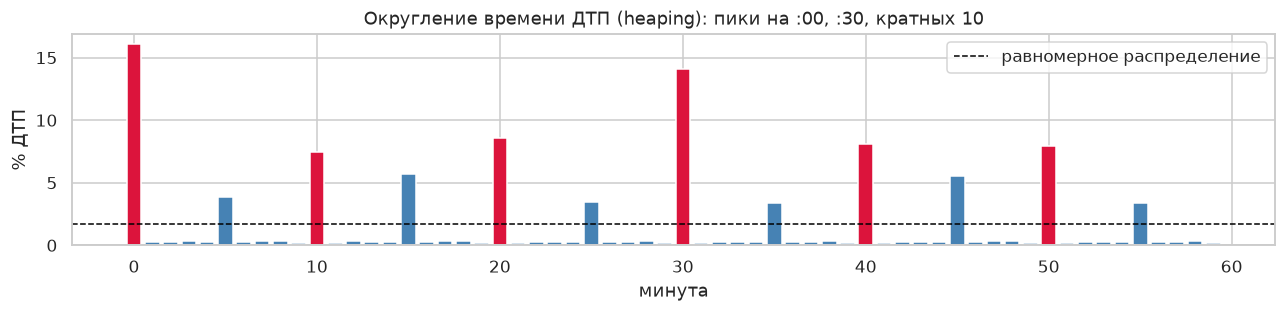

In [114]:
# округление минут
fig, ax = plt.subplots(figsize=(12, 3))
mc = minute.value_counts().sort_index()
ax.bar(mc.index, mc.values / len(acc) * 100, color=["crimson" if m_ % 10 == 0 else "steelblue" for m_ in mc.index])
ax.axhline(100 / 60, color="black", ls="--", lw=1, label="равномерное распределение")
ax.set_xlabel("минута"); ax.set_ylabel("% ДТП"); ax.set_title("Округление времени ДТП (heaping): пики на :00, :30, кратных 10")
ax.legend(); plt.tight_layout(); plt.show()

Инспекторы явно пишут время на глаз: почти треть ДТП приходится ровно на :00 или :30.

### 4.3. Как повлияет ошибка в 1% данных

Решил проверить на задаче: испортил 1% записей и посмотрел, насколько поменяется топ 1000 очагов.

,сценарий,jaccard,capture
0,исходные данные,1.000,0.1396
1,потеря 1% записей,0.959,0.1395
2,сдвиг 1% координат на 1–20 км,0.959,0.1395
3,1% координат → целые градусы,0.959,0.1381


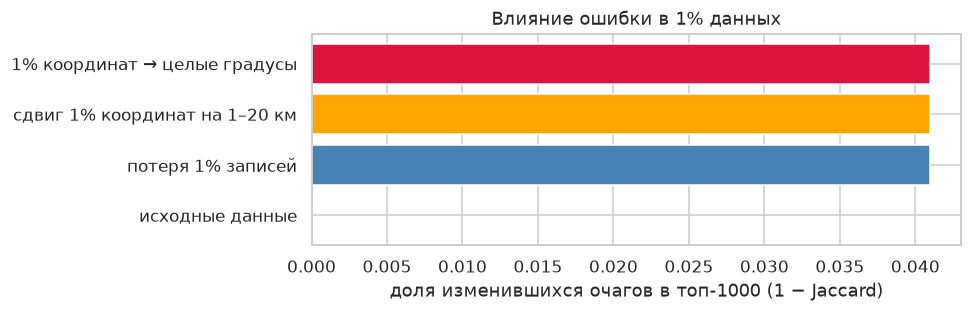

In [115]:
# порча 1 % записей: удаление, сдвиг, округление
TOP_N = 1000
base = acc[(acc["year"] == year_full) & acc["lat"].notna()][["lat", "lon", "reg_code", "settlement"]].copy()
base["cell"] = to_cell(base["lat"], base["lon"])
true_top = set(base["cell"].value_counts().head(TOP_N).index)
true_capture = base["cell"].isin(true_top).mean()

def top_cells(df):
    return set(to_cell(df["lat"], df["lon"]).value_counts().head(TOP_N).index)

def evaluate(df, name):
    top = top_cells(df)
    return dict(сценарий=name, jaccard=round(len(top & true_top) / len(top | true_top), 3),
                capture=round(base["cell"].isin(top).mean(), 4))

rng = np.random.default_rng(SEED)
idx = rng.choice(len(base), size=int(0.01 * len(base)), replace=False)

res = [dict(сценарий="исходные данные", jaccard=1.0, capture=round(true_capture, 4))]
res.append(evaluate(base.drop(base.index[idx]), "потеря 1% записей"))
shifted = base.copy()
dist = rng.uniform(1, 20, len(idx)); ang = rng.uniform(0, 2 * np.pi, len(idx))
shifted.iloc[idx, 0] += dist * np.sin(ang) / 111
shifted.iloc[idx, 1] += dist * np.cos(ang) / (111 * np.cos(np.radians(shifted.iloc[idx, 0])))
res.append(evaluate(shifted, "сдвиг 1% координат на 1–20 км"))
snapped = base.copy()
snapped.iloc[idx, 0] = np.floor(snapped.iloc[idx, 0]); snapped.iloc[idx, 1] = np.floor(snapped.iloc[idx, 1])
res.append(evaluate(snapped, "1% координат → целые градусы"))

impact = pd.DataFrame(res)
display(impact)

fig, ax = plt.subplots(figsize=(9, 3))
ax.barh(impact["сценарий"], 1 - impact["jaccard"], color=["grey", "steelblue", "orange", "crimson"])
ax.set_xlabel("доля изменившихся очагов в топ-1000 (1 − Jaccard)"); ax.set_title("Влияние ошибки в 1% данных")
plt.tight_layout(); plt.show()

Случайная ошибка почти ничего не меняет.

In [116]:
# доля артефактов по годам и в топе очагов
artifact = int_coord | (coord_rep > 50)
by_year_art = (artifact.groupby(acc["year"]).mean() * 100).round(2)
display(by_year_art.to_frame("% записей с «координатами по умолчанию»").T)

geo_all = acc[acc["lat"].notna()].assign(cell=cells, artifact=artifact[acc["lat"].notna()])
cell_art_share = geo_all.groupby("cell")["artifact"].mean()
ranked_all = geo_all["cell"].value_counts()
art_rows = []
for n in [10, 100, 1000]:
    top = ranked_all.head(n).index
    art_rows.append(dict(топ=n, **{"доля ячеек-артефактов": f"{(cell_art_share[top] > 0.5).mean():.0%}"}))
display(pd.DataFrame(art_rows))
print("Самые «опасные» ячейки за всю историю:")
display(geo_all[geo_all["cell"].isin(ranked_all.head(5).index)]
        .groupby("cell").agg(ДТП=("accident_id", "size"), регион=("reg_name", "first"),
                             lat=("lat", "median"), lon=("lon", "median"), артефактов=("artifact", "mean"))
        .sort_values("ДТП", ascending=False).round(3))

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
% записей с «координатами по умолчанию»,6.42,5.54,4.79,1.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,топ,доля ячеек-артефактов
0,10,90%
1,100,20%
2,1000,4%


Самые «опасные» ячейки за всю историю:


,ДТП,регион,lat,lon,артефактов
cell,,,,,
6327_3929,2573,Тюменская область,57.000,65.00,1.000
6549_1715,2132,гор. Санкт-Петербург,59.000,30.00,1.000
5217_2952,1514,Ростовская область,47.000,39.00,1.000
6105_4138,1480,Курганская область,55.000,65.00,1.000
6495_1811,1364,Новгородская область,58.517,31.25,0.899


Оказалось, что в 2015–2018 годах до 6 % координат это целые градусы, и 9 из 10 «самых опасных мест» по всей истории -
просто такие точки. Модель на этих данных отправляла бы наряды в чистое поле. Для моей задачи важнее всего координаты,
дата и тяжесть ДТП, а адреса и данные о машинах почти ни на что не влияют.

### 4.4. Что делать с плохими данными

Опечатки в адресах и округлённое время решил просто игнорировать, прогноз всё равно по дням. Пустые строки, типы,
регистр и дубли чищу автоматически. Подозрительные координаты помечаю и не беру в обучение, а регионы
со странными пропусками и недокачанные месяцы смотрю руками.

### 4.5. Проверка через Great Expectations

Сначала прогнал проверки на 2026 годе:

In [117]:
import great_expectations as gx
import logging
logging.getLogger("great_expectations").setLevel(logging.ERROR)
os.environ["GX_ANALYTICS_ENABLED"] = "False"

def prepare_partition(year: int) -> pd.DataFrame:
    df_ = acc[acc["year"] == year].copy()
    df_["victims_n"] = df_["dead_n"] + df_["injured_n"]
    df_["coord_is_integer"] = (df_["lat"] % 1 == 0) & (df_["lon"] % 1 == 0)
    return df_

latest_year = int(acc["year"].max())
batch_df = prepare_partition(latest_year)

context = gx.get_context(mode="ephemeral")
try:
    from great_expectations.data_context.types.base import ProgressBarsConfig
    context.variables.progress_bars = ProgressBarsConfig(globally=False)
except Exception:
    pass

source = context.data_sources.add_pandas("dtp")
asset = source.add_dataframe_asset("accidents")
batch_def = asset.add_batch_definition_whole_dataframe("latest_partition")
batch = batch_def.get_batch(batch_parameters={"dataframe": batch_df})

suite = context.suites.add(gx.ExpectationSuite(name="accidents_quality"))
E = gx.expectations
expectations = [
    E.ExpectColumnValuesToBeBetween(column="dead_n", min_value=0),
    E.ExpectColumnValuesToBeBetween(column="injured_n", min_value=0),
    E.ExpectColumnValuesToBeUnique(column="accident_id"),
    E.ExpectColumnValuesToNotBeNull(column="dt"),
    E.ExpectColumnValuesToBeBetween(column="lat", min_value=41.0, max_value=82.0),
    E.ExpectColumnValuesToBeBetween(column="lon", min_value=19.0, max_value=180.0),
    E.ExpectColumnValuesToNotBeNull(column="lat", mostly=0.98),
    E.ExpectColumnPairValuesAToBeGreaterThanB(column_A="participants_n", column_B="victims_n", or_equal=True),
    E.ExpectColumnValuesToBeBetween(column="victims_n", min_value=1),
    E.ExpectColumnValuesToBeBetween(column="m", min_value=0, max_value=999, mostly=0.9999),
    E.ExpectColumnValuesToBeBetween(column="km", min_value=0, max_value=2500, mostly=0.9999),
    E.ExpectColumnValuesToBeInSet(column="reg_code", value_set=[int(k) for k in reg_names]),
    E.ExpectColumnValuesToBeBetween(column="year", min_value=2015, max_value=latest_year),
    E.ExpectColumnValuesToBeBetween(column="month", min_value=1, max_value=12),
    E.ExpectColumnValuesToBeInSet(column="coord_is_integer", value_set=[False], mostly=0.999),
]
for e in expectations:
    suite.add_expectation(e)

validation = batch.validate(suite)
gx_report = pd.DataFrame([{
    "проверка": r.expectation_config.type,
    "колонка": r.expectation_config.kwargs.get("column", f"{r.expectation_config.kwargs.get('column_A')} ≥ "
                                                          f"{r.expectation_config.kwargs.get('column_B')}"),
    "успех": r.success,
    "нарушений": r.result.get("unexpected_count"),
    "доля нарушений, %": round(r.result.get("unexpected_percent") or 0, 4),
    "примеры": str(r.result.get("partial_unexpected_list", [])[:3]),
} for r in validation.results])
print(f"Партиция {latest_year}: {len(batch_df):,} строк; общий результат: {'OK' if validation.success else 'ЕСТЬ НАРУШЕНИЯ'}")
gx_report

Партиция 2026: 79,977 строк; общий результат: OK


,проверка,колонка,успех,нарушений,"доля нарушений, %",примеры
0,expect_column_values_to_be_between,dead_n,True,0,0,[]
1,expect_column_values_to_be_between,injured_n,True,0,0,[]
2,expect_column_values_to_be_unique,accident_id,True,0,0,[]
3,expect_column_values_to_not_be_null,dt,True,0,0,[]
4,expect_column_values_to_be_between,lat,True,0,0,[]
5,expect_column_values_to_not_be_null,lat,True,0,0,[]
6,expect_column_values_to_be_between,lon,True,0,0,[]
7,expect_column_pair_values_a_to_be_greater_than_b,participants_n ≥ victims_n,True,0,0,[]
8,expect_column_values_to_be_between,victims_n,True,0,0,[]
9,expect_column_values_to_be_between,m,True,0,0,[]


In [118]:
# те же проверки по всем годам
per_year = []
for y in sorted(acc["year"].unique()):
    res_y = batch_def.get_batch(batch_parameters={"dataframe": prepare_partition(int(y))}).validate(suite)
    failed = [f"{r.expectation_config.kwargs.get('column', 'pair')} ({r.result.get('unexpected_count')})"
              for r in res_y.results if not r.success]
    per_year.append(dict(год=int(y), результат="OK" if res_y.success else "FAIL", **{"проваленные проверки": ", ".join(failed)}))
pd.DataFrame(per_year)

,год,результат,проваленные проверки
0,2015,FAIL,"lat (7676), coord_is_integer (10494)"
1,2016,FAIL,coord_is_integer (7520)
2,2017,FAIL,coord_is_integer (6255)
3,2018,FAIL,coord_is_integer (1456)
4,2019,OK,
5,2020,FAIL,victims_n (1)
6,2021,OK,
7,2022,OK,
8,2023,OK,
9,2024,OK,


Потом прогнал по всем годам, проверка на целые градусы как раз ловит 2015–2018.

### 4.6. Как часто проверять

Думаю, набор GX стоит запускать при каждой загрузке, раз в месяц сверять raw с clean и перекачивать последние месяцы,
а раз в неделю смотреть, не поплыли ли распределения.

**Вывод.** Счётчикам доверять можно, а вот с координатами и временем проблемы системные. Случайная ошибка в 1%
почти не влияет на результат. Поэтому в пайплайне нужна проверка
качества на входе и возможность перезаписать период задним числом.

## Часть 5. Value

### 5.1. Сколько стоят ДТП

Ущерб оценил по нормативам РосдорНИИ: смерть - 21,72 млн Руб, ранение - 0,755 млн Руб, плюс 0,296 млн Руб материального ущерба на ДТП.

Для анализа ценности оставлено 1,683,147 из 1,730,272 ДТП (97.3%)


,ДТП,погибло,ранено,"ущерб, млрд ₽"
year,,,,
2015,183692,23068,230812,730.0
2016,172051,20041,219115,652.0
2017,168133,18901,213728,622.0
2018,167024,18044,213478,603.0
2019,162885,16795,209105,571.0
2020,144143,16040,181870,528.0
2021,132511,14785,166870,486.0
2022,126658,14169,159583,466.0
2023,132434,14500,166460,480.0


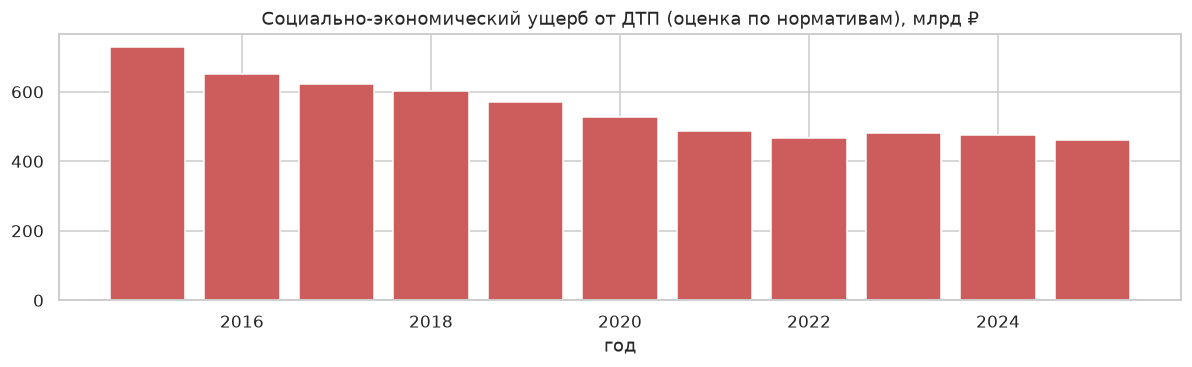

In [119]:
# ущерб по нормативам; артефакты исключены
DAMAGE = {"dead": 21.72e6, "injured": 0.755e6, "material": 0.296e6}

good = acc[acc["lat"].notna() & ~int_coord & (coord_rep <= 50) & ~far].copy()
good["cell"] = to_cell(good["lat"], good["lon"])
good["damage"] = good["dead_n"] * DAMAGE["dead"] + good["injured_n"] * DAMAGE["injured"] + DAMAGE["material"]
print(f"Для анализа ценности оставлено {len(good):,} из {len(acc):,} ДТП ({len(good)/len(acc):.1%})")

by_year = acc.groupby("year").agg(ДТП=("accident_id", "size"), погибло=("dead_n", "sum"), ранено=("injured_n", "sum"))
by_year["ущерб, млрд ₽"] = ((by_year["погибло"] * DAMAGE["dead"] + by_year["ранено"] * DAMAGE["injured"]
                             + by_year["ДТП"] * DAMAGE["material"]) / 1e9).round(0)
display(by_year)

fig, ax = plt.subplots(figsize=(11, 3.5))
full_years = by_year.loc[by_year.index < by_year.index.max()]
ax.bar(full_years.index, full_years["ущерб, млрд ₽"], color="indianred")
ax.set_title("Социально-экономический ущерб от ДТП (оценка по нормативам), млрд ₽"); ax.set_xlabel("год")
plt.tight_layout(); plt.show()

Получилось около 460 млрд ₽ в год. Даже доля процента от этого уже большие деньги.

### 5.2. ABC-анализ

Проверил, работает ли правило Парето для квадратов на карте.

,ячеек (по числу ДТП),"доля ячеек, % (ДТП)",ячеек (по ущербу),"доля ячеек, % (ущерб)"
class,,,,
A,50500,39.2,31470,24.4
B,58742,45.6,38670,30.0
C,19660,15.3,58762,45.6


Топ-1% ячеек дают 16.0% ДТП и 10.1% ущерба
Топ-5% ячеек дают 41.2% ДТП и 31.9% ущерба
Топ-20% ячеек дают 66.4% ДТП и 71.2% ущерба


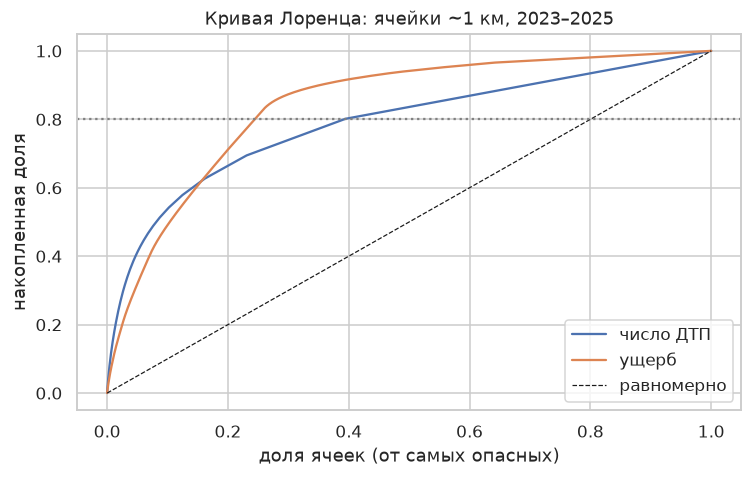

In [120]:
# ABC-анализ квадратов за 3 года
last3 = good[good["year"].between(year_full - 2, year_full)]
cell_val = last3.groupby("cell").agg(n=("accident_id", "size"), damage=("damage", "sum"))

def abc(series: pd.Series) -> pd.DataFrame:
    s = series.sort_values(ascending=False)
    cum = s.cumsum() / s.sum()
    cls = np.where(cum <= 0.80, "A", np.where(cum <= 0.95, "B", "C"))
    return pd.DataFrame({"value": s, "cum_share": cum, "class": cls})

abc_n = abc(cell_val["n"]); abc_d = abc(cell_val["damage"])
abc_table = pd.DataFrame({
    "ячеек (по числу ДТП)": abc_n["class"].value_counts(),
    "доля ячеек, % (ДТП)": (abc_n["class"].value_counts(normalize=True) * 100).round(1),
    "ячеек (по ущербу)": abc_d["class"].value_counts(),
    "доля ячеек, % (ущерб)": (abc_d["class"].value_counts(normalize=True) * 100).round(1),
}).sort_index()
display(abc_table)
for share in [0.01, 0.05, 0.20]:
    k = int(len(abc_n) * share)
    print(f"Топ-{share:.0%} ячеек дают {abc_n['cum_share'].iloc[k-1]:.1%} ДТП и {abc_d['cum_share'].iloc[k-1]:.1%} ущерба")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(1, len(abc_n) + 1) / len(abc_n)
ax.plot(x, abc_n["cum_share"].values, label="число ДТП")
ax.plot(x, abc_d["cum_share"].values, label="ущерб")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="равномерно")
ax.axhline(0.8, color="grey", ls=":"); ax.set_xlabel("доля ячеек (от самых опасных)"); ax.set_ylabel("накопленная доля")
ax.set_title(f"Кривая Лоренца: ячейки ~1 км, {year_full-2}–{year_full}"); ax.legend(); plt.tight_layout(); plt.show()

Работает наполовину: 20 % квадратов дают примерно две трети ДТП. Поэтому координаты, время и тяжесть ДТП обрабатываю
каждый день, погоду и тип дороги беру как признаки, а данные о машинах и участниках можно не трогать.

### 5.3. Больше данных - больше пользы?

Ранжировал квадраты по истории за разное число лет и посмотрел, сколько ДТП следующего года попадает в топ-1000.

,лет_истории,записей_млн,capture,PAI
0,1,0.1320,0.1194,40.7073
1,2,0.2644,0.1242,42.3622
2,3,0.3911,0.1246,42.4708
3,4,0.5236,0.1244,42.4311
4,5,0.6677,0.1245,42.4417
5,6,0.8306,0.1235,42.1133
6,7,0.9950,0.1235,42.1054
7,8,1.1516,0.1231,41.9862
8,9,1.3105,0.1229,41.9068
9,10,1.4744,0.1220,41.5864


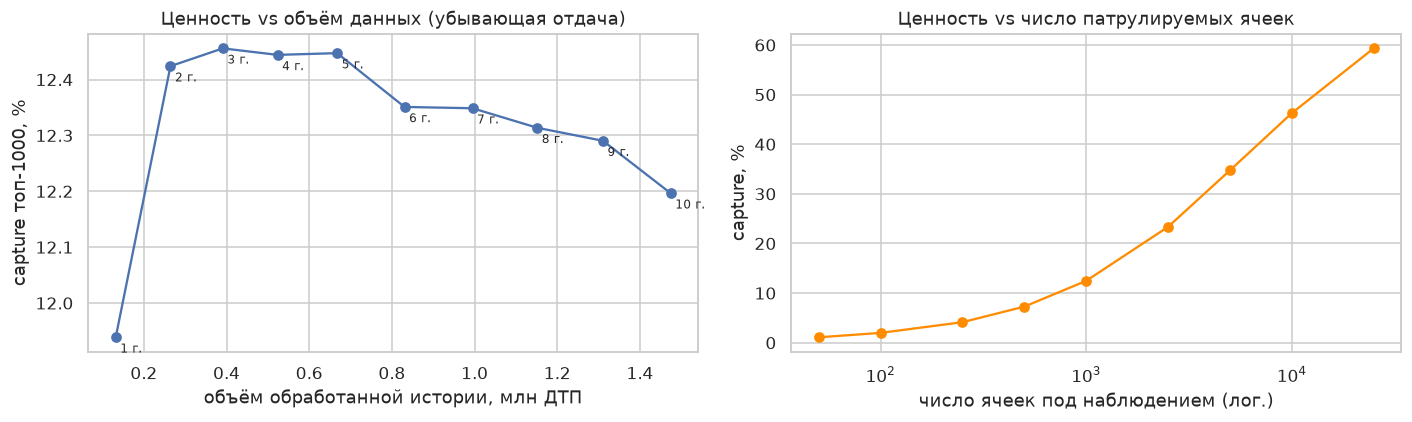

In [121]:
# capture и PAI от длины истории
TARGET = year_full
N_CELLS = 1000
target_cells = good.loc[good["year"] == TARGET, "cell"]
n_active_cells = good["cell"].nunique()

rows = []
for k in range(1, 11):
    hist = good[good["year"].between(TARGET - k, TARGET - 1)]
    if hist["year"].nunique() < k:
        break
    top = hist["cell"].value_counts().head(N_CELLS).index
    capture = target_cells.isin(top).mean()
    rows.append(dict(лет_истории=k, записей_млн=len(hist) / 1e6, capture=capture,
                     PAI=capture / (N_CELLS / n_active_cells)))
learn = pd.DataFrame(rows)
display(learn.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(learn["записей_млн"], learn["capture"] * 100, "o-")
for _, r in learn.iterrows():
    axes[0].annotate(f"{int(r['лет_истории'])} г.", (r["записей_млн"], r["capture"] * 100), fontsize=8,
                     xytext=(3, -10), textcoords="offset points")
axes[0].set_xlabel("объём обработанной истории, млн ДТП"); axes[0].set_ylabel(f"capture топ-{N_CELLS}, %")
axes[0].set_title("Ценность vs объём данных (убывающая отдача)")

hist3 = good[good["year"].between(TARGET - 3, TARGET - 1)]["cell"].value_counts()
Ns = [50, 100, 250, 500, 1000, 2500, 5000, 10000, 25000]
cov = [target_cells.isin(hist3.head(n).index).mean() * 100 for n in Ns]
axes[1].plot(Ns, cov, "o-", color="darkorange"); axes[1].set_xscale("log")
axes[1].set_xlabel("число ячеек под наблюдением (лог.)"); axes[1].set_ylabel("capture, %")
axes[1].set_title("Ценность vs число патрулируемых ячеек")
plt.tight_layout(); plt.show()

После трёх лет истории польза перестаёт расти - старые данные описывают уже другие дороги.

### 5.4. ROI на примере Кузбасса

Для пилота взял регион Кемеровской области. Допустил, что наряды стоят в 30 самых опасных квадратах и снижают там ДТП на 3, 7 или 15 %.

In [122]:
# ROI пилота
PILOT_REG = 1132
N_PILOT = 30
reg = good[good["reg_code"] == PILOT_REG]
reg_hist = reg[reg["year"].between(TARGET - 3, TARGET - 1)]["cell"].value_counts()
reg_target = reg[reg["year"] == TARGET]
pilot_top = reg_hist.head(N_PILOT).index
covered = reg_target[reg_target["cell"].isin(pilot_top)]
pilot_capture = len(covered) / len(reg_target)
damage_covered = covered["damage"].sum()
print(f"Регион: {reg_names.get(PILOT_REG)}; ДТП в {TARGET}: {len(reg_target):,}; ущерб: {reg_target['damage'].sum()/1e9:.2f} млрд Руб")
print(f"Топ-{N_PILOT} ячеек захватывают {pilot_capture:.1%} ДТП и {damage_covered/1e6:,.0f} млн Руб ущерба в год")

COSTS = {
    "разработка (2 чел × 6 мес × 250 тыс Руб)": 2 * 6 * 250_000,
    "инфраструктура, год (ВМ ~20 тыс Руб/мес)": 20_000 * 12,
    "хранение, год (Object Storage, см. 1.6)": cost["Руб в год"].iloc[[1, 2, 4]].sum(),
    "сопровождение, год (0,25 ставки)": 0.25 * 250_000 * 12,
}
capex = COSTS["разработка (2 чел × 6 мес × 250 тыс Руб)"]
opex_year = sum(v for k, v in COSTS.items() if "год" in k)
display(pd.Series(COSTS, name="Руб").round(0).to_frame())

roi_rows = []
for name, effect in [("пессимистичный", 0.03), ("базовый", 0.07), ("целевой", 0.15)]:
    benefit_year = damage_covered * effect
    roi_1y = (benefit_year - capex - opex_year) / (capex + opex_year)
    payback_m = capex / max(benefit_year / 12 - opex_year / 12, 1e-9)
    roi_rows.append(dict(сценарий=name, эффект=f"{effect:.0%}", **{
        "предотвращённый ущерб, млн Руб/год": round(benefit_year / 1e6, 1),
        "затраты 1-го года, млн Руб": round((capex + opex_year) / 1e6, 2),
        "ROI 1-го года": f"{roi_1y:.0%}",
        "окупаемость, мес": round(payback_m, 1)}))
roi = pd.DataFrame(roi_rows)
roi

Регион: Кемеровская область - Кузбасс; ДТП в 2025: 2,261; ущерб: 7.72 млрд Руб
Топ-30 ячеек захватывают 11.0% ДТП и 400 млн Руб ущерба в год


,Руб
разработка (2 чел × 6 мес × 250 тыс Руб),3000000.0
"инфраструктура, год (ВМ ~20 тыс Руб/мес)",240000.0
"хранение, год (Object Storage, см. 1.6)",381.0
"сопровождение, год (0,25 ставки)",750000.0


,сценарий,эффект,"предотвращённый ущерб, млн Руб/год","затраты 1-го года, млн Руб",ROI 1-го года,"окупаемость, мес"
0,пессимистичный,3%,12.0,3.99,201%,3.3
1,базовый,7%,28.0,3.99,601%,1.3
2,целевой,15%,60.0,3.99,1403%,0.6


Точка безубыточности 1-го года: снижение ДТП в покрытых ячейках на 1.00%


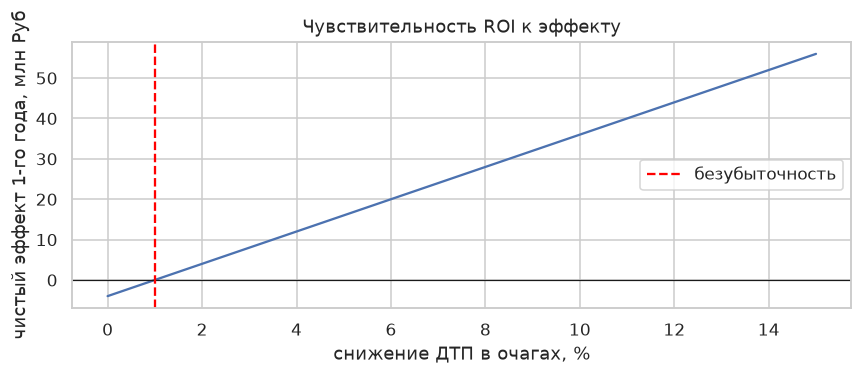

In [123]:
# точка безубыточности
break_even_effect = (capex + opex_year) / damage_covered
print(f"Точка безубыточности 1-го года: снижение ДТП в покрытых ячейках на {break_even_effect:.2%}")

effects = np.linspace(0, 0.15, 31)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(effects * 100, (damage_covered * effects - capex - opex_year) / 1e6)
ax.axhline(0, color="k", lw=0.8); ax.axvline(break_even_effect * 100, color="red", ls="--", label="безубыточность")
ax.set_xlabel("снижение ДТП в очагах, %"); ax.set_ylabel("чистый эффект 1-го года, млн Руб")
ax.set_title("Чувствительность ROI к эффекту"); ax.legend(); plt.tight_layout(); plt.show()

Цифры выходят очень хорошие, потому что одна смерть по нормативу стоит больше 20 млн Руб, а вся система - около 4 млн.

### 5.5. Что будет с ценностью через год

,"capture, % (среднее по годам)"
горизонт,
1,12.01
2,11.63
3,11.33
4,11.05
5,10.76


За 1 год ценность «старого» рейтинга очагов падает на 3% относительно горизонта 1 год -> 5 лет: −10%


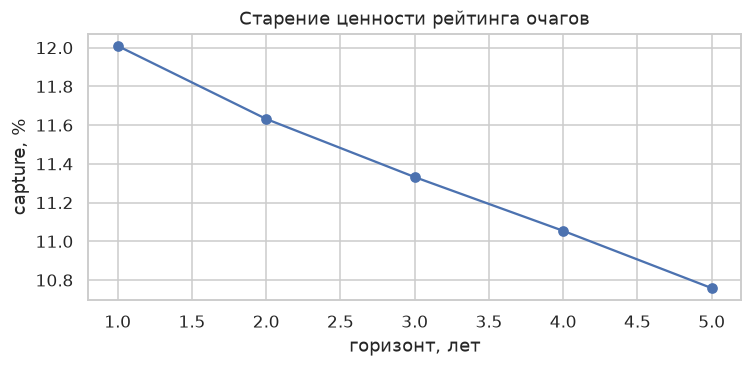

In [124]:
# старение рейтинга очагов
decay = []
for t in range(2015, TARGET):
    top_t = good.loc[good["year"] == t, "cell"].value_counts().head(N_CELLS).index
    for h in range(1, 6):
        if t + h > TARGET:
            break
        tgt = good.loc[good["year"] == t + h, "cell"]
        decay.append(dict(t=t, горизонт=h, capture=tgt.isin(top_t).mean()))
decay = pd.DataFrame(decay)
decay_mean = decay.groupby("горизонт")["capture"].mean()
display((decay_mean * 100).round(2).to_frame("capture, % (среднее по годам)"))
print(f"За 1 год ценность «старого» рейтинга очагов падает на {(1 - decay_mean.iloc[1] / decay_mean.iloc[0]):.0%} "
      f"относительно горизонта 1 год -> {decay_mean.index[-1]} лет: −{(1 - decay_mean.iloc[-1] / decay_mean.iloc[0]):.0%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(decay_mean.index, decay_mean.values * 100, "o-")
ax.set_xlabel("горизонт, лет"); ax.set_ylabel("capture, %"); ax.set_title("Старение ценности рейтинга очагов")
plt.tight_layout(); plt.show()

Рейтинг стареет медленно, примерно на 3 % в год.

### 5.6. Мониторинг

После запуска я бы раз в месяц смотрел, какую долю ДТП ловит прогноз и есть ли разница с контрольными квадратами,
каждый день - свежесть данных, а ROI пересчитывал бы раз в квартал.

**Вывод.** Данные очень ценные, затраты точно оправданы: проект окупается уже при снижении ДТП в очагах на 1%.
Главная сложность не в деньгах, а в том, чтобы доказать, что эффект дала именно система.

## Часть 6. Выбор технологий

Если свести всё вместе: данных мало, приходят они медленно, а основные проблемы во вложенности и качестве.
Поэтому решил не брать тяжёлые инструменты и собрать всё на одной машине.

### 6.1. Стек

In [131]:
stack = pd.DataFrame([
    ["Хранение", "Object Storage + Parquet, Iceberg", "дёшево, перезапись задним числом",
     "лишний каталог метаданных", "HDFS - нужен кластер"],
    ["Обработка", "DuckDB + pandas", "SQL по Parquet и JSON, хватает одной машины",
     "один узел", "Spark - избыточен для ГБ"],
    ["Загрузка", "Python-загрузчик с манифестом", "контроль полноты, ретраи",
     "зависит от API ГИБДД", "Kafka - нет потока событий"],
    ["Качество", "Great Expectations", "не пускает битые данные дальше",
     "тяжёлая библиотека", "Soda, dbt tests"],
    ["ML", "MLflow + LightGBM", "версии моделей, повторяемость",
     "нужен сервер MLflow", "Feature Store - избыточен"],
    ["Оркестрация", "Airflow", "расписание, ретраи, backfill",
     "отдельный сервис", "cron - без ретраев"],
    ["Гео", "H3 + GeoPandas", "равные ячейки, проверка региона",
     "ячейки не совпадают с дорогами", "сетка в градусах"],
    ["Выдача", "PostGIS + дашборд", "карта очагов на смену",
     "нужно разграничение доступа", "отчёты в файлах"],
], columns=["слой", "выбор", "зачем", "ограничения", "альтернатива"])
stack

,слой,выбор,зачем,ограничения,альтернатива
0,Хранение,"Object Storage + Parquet, Iceberg","дёшево, перезапись задним числом",лишний каталог метаданных,HDFS - нужен кластер
1,Обработка,DuckDB + pandas,"SQL по Parquet и JSON, хватает одной машины",один узел,Spark - избыточен для ГБ
2,Загрузка,Python-загрузчик с манифестом,"контроль полноты, ретраи",зависит от API ГИБДД,Kafka - нет потока событий
3,Качество,Great Expectations,не пускает битые данные дальше,тяжёлая библиотека,"Soda, dbt tests"
4,ML,MLflow + LightGBM,"версии моделей, повторяемость",нужен сервер MLflow,Feature Store - избыточен
5,Оркестрация,Airflow,"расписание, ретраи, backfill",отдельный сервис,cron - без ретраев
6,Гео,H3 + GeoPandas,"равные ячейки, проверка региона",ячейки не совпадают с дорогами,сетка в градусах
7,Выдача,PostGIS + дашборд,карта очагов на смену,нужно разграничение доступа,отчёты в файлах


### 6.2. Архитектура

Схема получилась такая:

```mermaid
flowchart LR
    subgraph SRC[Источники]
        A1[API stat.gibdd.ru<br/>карточки ДТП, помесячно]
        A2[Прогноз погоды<br/>на сутки D]
        A3[Календарь праздников]
    end
    subgraph ING[Загрузка]
        B1[Python-загрузчик<br/>ретраи + manifest.jsonl]
    end
    subgraph LAKE[Object Storage: S3 + Iceberg]
        C1[(bronze: raw json.zst)]
        C2[(silver: accidents / participants / vehicles)]
        C3[(gold: features cell×day)]
        C4[(predictions day=D)]
    end
    subgraph PROC[Обработка: DuckDB / pandas]
        D1[Парсинг и нормализация]
        D2{Great Expectations}
        D3[Сборка признаков H3]
        D4[Обучение: LightGBM + MLflow]
        D5[Инференс: прогноз на D]
    end
    subgraph OUT[Потребители]
        E1[Витрина PostGIS]
        E2[Дашборд очагов]
        E3[API для диспетчеров ДПС/СМП]
    end
    A1 --> B1 --> C1 --> D1 --> D2
    D2 -- OK --> C2 --> D3 --> C3
    D2 -- FAIL --> X[Алерт, партиция не публикуется]
    C3 --> D4 --> D5
    A2 --> D5
    A3 --> D3
    D5 --> C4 --> E1 --> E2
    E1 --> E3
    AF([Airflow: ежедневно 12:00 UTC, ежемесячно - перезагрузка 3 мес.]) -.-> B1 & D1 & D3 & D4 & D5
```

In [126]:
dag = pd.DataFrame([
    ["ingest_month", "ежемесячно, 5-е число", "перезагрузка последних 3 месяцев по всем регионам", "~10 мин"],
    ["parse_validate", "после ingest", "raw → silver, Great Expectations, upsert по accident_id", "~1 мин"],
    ["build_features", "ежедневно 12:00 UTC", "silver + календарь → gold (ячейка×сутки)", f"~{t_features:.0f} с"],
    ["train_model", "ежемесячно", "переобучение, регистрация в MLflow при росте capture", "минуты"],
    ["predict_day", "ежедневно 13:00 UTC", "прогноз на D по сценариям погоды → predictions", f"~{run['seconds']:.0f} с"],
    ["publish", "после predict_day, дедлайн 18:00 UTC", "витрина + дашборд + уведомления регионам", "секунды"],
], columns=["задача DAG", "расписание", "что делает", "время (оценка)"])
dag

,задача DAG,расписание,что делает,время (оценка)
0,ingest_month,"ежемесячно, 5-е число",перезагрузка последних 3 месяцев по всем регионам,~10 мин
1,parse_validate,после ingest,"raw → silver, Great Expectations, upsert по accident_id",~1 мин
2,build_features,ежедневно 12:00 UTC,silver + календарь → gold (ячейка×сутки),~2 с
3,train_model,ежемесячно,"переобучение, регистрация в MLflow при росте capture",минуты
4,predict_day,ежедневно 13:00 UTC,прогноз на D по сценариям погоды → predictions,~21 с
5,publish,"после predict_day, дедлайн 18:00 UTC",витрина + дашборд + уведомления регионам,секунды


### 6.3. Ресурсы

In [132]:
resources = pd.DataFrame([
    ["ВМ обработки + Airflow + MLflow", "1 × 8 vCPU / 32 ГБ RAM / 100 ГБ SSD",
     f"пайплайн ~{t_processing:.0f} с/сутки на 1 ядре; RAM с 5× запасом к {human(pandas_total)} данных в pandas"],
    ["Object Storage", f"≈ {(current['clean Parquet (3 табл.)'] + current['raw json.zst'] + pred_year_gb * GB) / GB:.0f} ГБ за первый год",
     "clean + raw + прогнозы за год (с политикой хранения 90 дней - ещё меньше)"],
    ["PostgreSQL/PostGIS (витрина)", "managed, 2 vCPU / 8 ГБ", "только актуальные прогнозы + агрегаты"],
    ["Сеть", "< 1 ГБ/мес исходящего трафика", "дашборд и API отдают агрегаты"],
], columns=["компонент", "размер", "обоснование"])
resources

,компонент,размер,обоснование
0,ВМ обработки + Airflow + MLflow,1 × 8 vCPU / 32 ГБ RAM / 100 ГБ SSD,пайплайн ~23 с/сутки на 1 ядре; RAM с 5× запасом к 2.4 ГБ данных в pandas
1,Object Storage,≈ 26 ГБ за первый год,clean + raw + прогнозы за год (с политикой хранения 90 дней - ещё меньше)
2,PostgreSQL/PostGIS (витрина),"managed, 2 vCPU / 8 ГБ",только актуальные прогнозы + агрегаты
3,Сеть,< 1 ГБ/мес исходящего трафика,дашборд и API отдают агрегаты


### 6.4. Как перейти от текущего состояния

Сейчас всё лежит у меня локально и запускается руками. Сначала перенесу данные в Object Storage и переведу таблицы
на Iceberg, потом встрою проверки GX в парсер, заверну всё в Airflow, подключу MLflow и в конце сделаю дашборд для пилотного региона.

### 6.5. Риски

In [133]:
risks = pd.DataFrame([
    ["API ГИБДД меняет формат/недоступен", "высокая", "нет новых данных",
     "raw хранится как есть; контракт-тесты схемы; прогноз продолжает работать на истории + погоде"],
    ["Систематические ошибки геопривязки", "высокая", "ложные очаги в центрах городов",
     "фильтры 4.4, проверка point-in-polygon, ручной разбор топ-очагов перед публикацией"],
    ["Пересмотр «предварительных» карточек", "средняя", "расхождение прогноз/факт, дрейф",
     "ежемесячная перезагрузка 3 мес., идемпотентный MERGE по accident_id"],
    ["Нет доказательства эффекта", "средняя", "проект сочтут бесполезным",
     "рандомизация покрытия ячеек (контрольная группа), заранее согласованная метрика"],
    ["Смещение модели → «самосбывающийся» прогноз", "средняя", "наряды фиксируют больше ДТП там, где стоят",
     "метрика по ДТП с пострадавшими (регистрируются всегда), а не по нарушениям"],
    ["Чувствительность данных (ПДн участников)", "низкая", "юридические риски",
     "в ML-контуре только агрегаты по ячейкам; participants/vehicles - в закрытом архиве"],
    ["Дедлайн 06:00 на Дальнем Востоке", "низкая", "прогноз опаздывает",
     "запуск в 12–13 UTC, SLA-алерт Airflow, fallback - прогноз прошлого дня"],
], columns=["риск", "вероятность", "последствие", "как минимизируем"])
risks

,риск,вероятность,последствие,как минимизируем
0,API ГИБДД меняет формат/недоступен,высокая,нет новых данных,raw хранится как есть; контракт-тесты схемы; прогноз продолжает работать на ...
1,Систематические ошибки геопривязки,высокая,ложные очаги в центрах городов,"фильтры 4.4, проверка point-in-polygon, ручной разбор топ-очагов перед публи..."
2,Пересмотр «предварительных» карточек,средняя,"расхождение прогноз/факт, дрейф","ежемесячная перезагрузка 3 мес., идемпотентный MERGE по accident_id"
3,Нет доказательства эффекта,средняя,проект сочтут бесполезным,"рандомизация покрытия ячеек (контрольная группа), заранее согласованная метрика"
4,Смещение модели → «самосбывающийся» прогноз,средняя,"наряды фиксируют больше ДТП там, где стоят","метрика по ДТП с пострадавшими (регистрируются всегда), а не по нарушениям"
5,Чувствительность данных (ПДн участников),низкая,юридические риски,в ML-контуре только агрегаты по ячейкам; participants/vehicles - в закрытом ...
6,Дедлайн 06:00 на Дальнем Востоке,низкая,прогноз опаздывает,"запуск в 12–13 UTC, SLA-алерт Airflow, fallback - прогноз прошлого дня"


### 6.6. План на полгода

In [129]:
roadmap = pd.DataFrame([
    ["Месяц 1", "Инфраструктура и данные", "Object Storage, перенос raw/clean, Iceberg, исправление схемы",
     "100 % данных в облаке; сверка raw↔clean = 0 расхождений"],
    ["Месяц 2", "Пайплайн и качество", "DAG Airflow (ingest -> parse -> validate), набор GX, фильтры геопривязки",
     "ежедневный прогон без ручного участия >= 7 дней подряд; 0 публикаций битых партиций"],
    ["Месяц 3", "Модель", "признаки H3 + погода/праздники, LightGBM, MLflow, backtest",
     "capture@1000 и PAI выше базовой эвристики «история 3 года» (5.3) на >= 10 %"],
    ["Месяц 4", "Пилот: Кузбасс", "витрина + дашборд, прогноз на смену для ГИБДД региона, контрольная группа ячеек",
     "прогноз готов до 06:00 местного времени в 100 % дней"],
    ["Месяц 5", "Оценка эффекта", "сравнение покрытых и контрольных ячеек, опрос пользователей",
     "снижение ДТП с пострадавшими в покрытых ячейках >= 7 % (базовый сценарий)"],
    ["Месяц 6", "Масштабирование", "подключение 3–5 регионов, мониторинг ценности, пересчёт ROI",
     "ROI ≥ базового сценария; доступность сервиса >= 99 %"],
], columns=["срок", "этап", "работы", "метрика успеха"])
roadmap

,срок,этап,работы,метрика успеха
0,Месяц 1,Инфраструктура и данные,"Object Storage, перенос raw/clean, Iceberg, исправление схемы",100 % данных в облаке; сверка raw↔clean = 0 расхождений
1,Месяц 2,Пайплайн и качество,"DAG Airflow (ingest -> parse -> validate), набор GX, фильтры геопривязки",ежедневный прогон без ручного участия >= 7 дней подряд; 0 публикаций битых п...
2,Месяц 3,Модель,"признаки H3 + погода/праздники, LightGBM, MLflow, backtest",capture@1000 и PAI выше базовой эвристики «история 3 года» (5.3) на >= 10 %
3,Месяц 4,Пилот: Кузбасс,"витрина + дашборд, прогноз на смену для ГИБДД региона, контрольная группа ячеек",прогноз готов до 06:00 местного времени в 100 % дней
4,Месяц 5,Оценка эффекта,"сравнение покрытых и контрольных ячеек, опрос пользователей",снижение ДТП с пострадавшими в покрытых ячейках >= 7 % (базовый сценарий)
5,Месяц 6,Масштабирование,"подключение 3–5 регионов, мониторинг ценности, пересчёт ROI",ROI ≥ базового сценария; доступность сервиса >= 99 %


**Вывод.** Spark, Kafka и Flink при таких объёмах только добавили бы сложности. Хватит Object Storage с Parquet и Iceberg,
DuckDB, Airflow, MLflow и Great Expectations.

## Заключение

In [130]:
parquet_ratio = fmt.loc[fmt["формат"] == "Parquet (zstd)", "сжатие vs CSV"].iloc[0]
summary = pd.DataFrame([
    ["Volume", f"{human(inv['байт'].sum())} на диске, Parquet в {parquet_ratio:.0f}× меньше CSV",
     "Spark не нужен"],
    ["Velocity", f"~{len(acc)/period_sec*86400:.0f} ДТП/сутки, лаг источника {source_lag.days} сут.",
     "batch раз в сутки"],
    ["Variety", "вложенный JSON, списки, гео",
     "Parquet, DuckDB, H3"],
    ["Veracity", f"{quality.loc['пропуск координат (lat/lon)', 'доля, %']:.1f}% без координат, "
                 f"{quality.loc['время округлено до :00 или :30', 'доля, %']:.0f}% времени округлено",
     "проверки GX, фильтры"],
    ["Value", f"окупается при снижении ДТП на {break_even_effect:.0%}",
     "затраты оправданы"],
], columns=["V", "цифры", "решение"])
summary

,V,цифры,решение
0,Volume,"615.8 МБ на диске, Parquet в 19× меньше CSV",Spark не нужен
1,Velocity,"~406 ДТП/сутки, лаг источника 20 сут.",batch раз в сутки
2,Variety,"вложенный JSON, списки, гео","Parquet, DuckDB, H3"
3,Veracity,"0.9% без координат, 30% времени округлено","проверки GX, фильтры"
4,Value,окупается при снижении ДТП на 1%,затраты оправданы


В итоге получилось, что данные о ДТП «большие» не по объёму и не по скорости, а по сложности и качеству.
При этом они очень ценные - ущерб от ДТП сотни миллиардов рублей в год. Поэтому я бы строил лёгкую систему
с прогнозом раз в день и начинал с пилота в Кузбассе.